# TPC 분석

### 📊 최적 임계값 (TPE Sampler 결과)

| **항목**           | **값**    | **설명**                           |
|--------------------|-----------|------------------------------------|
| **Best TPC Low**   | `4.211`   | 신선 임계값 (Fresh < 4.211)        |
| **Best TPC High**  | `6.233`   | 부패 임계값 (Decay ≥ 6.233)        |
| **Best Score**     | `198.93`  | 최적화 점수 (QMC 대비 +1.85 향상)  |

```
신선(Fresh):   TPC < 4.211
중간(Middle):  4.211 ≤ TPC < 6.233  
부패(Decay):   TPC ≥ 6.233
```

### 📈 라벨 분포
- **Fresh (신선)**: 139개 (51.5%)
- **Decay (부패)**: 48개 (17.8%)
- **Middle (중간)**: 83개 (30.7%)

## .pkl 파일 불러오기

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import os

# 전처리된 데이터 불러오기
save_dir = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl"

print("=== 전처리된 데이터 불러오기 ===")

# 1. 최종 데이터만 불러오기 (final_taxonomic_levels)
all_data_path = os.path.join(save_dir, "all_preprocessed_data.pkl")

if os.path.exists(all_data_path):
    with open(all_data_path, 'rb') as f:
        preprocessed_data = pickle.load(f)
    final_taxonomic_levels = preprocessed_data['final_taxonomic_levels']
    print(f"✅ 최종 데이터 로드 완료")
    print(f"총 taxonomy level 수: {len(final_taxonomic_levels)}")
else:
    print(f"❌ 통합 데이터 파일을 찾을 수 없습니다: {all_data_path}")

# 2. ANOVA 결과 불러오기
anova_results_path = os.path.join(save_dir, "anova_results.pkl")
if os.path.exists(anova_results_path):
    with open(anova_results_path, 'rb') as f:
        anova_results = pickle.load(f)
    print(f"✅ ANOVA 결과 로드 완료")
else:
    print(f"❌ ANOVA 결과 파일을 찾을 수 없습니다: {anova_results_path}")

# 3. 변화량 분석 결과 불러오기
change_analysis_path = os.path.join(save_dir, "change_analysis_results.pkl")
if os.path.exists(change_analysis_path):
    with open(change_analysis_path, 'rb') as f:
        change_analysis_results = pickle.load(f)
    print(f"✅ 변화량 분석 결과 로드 완료")
else:
    print(f"❌ 변화량 분석 결과 파일을 찾을 수 없습니다: {change_analysis_path}")

# 4. ANOVA 결과 검토 (상위 5개 feature만 표시)
print(f"\n=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in anova_results:
        anova_result_df = anova_results[level_name]['anova_result']
        significant_features = anova_results[level_name]['significant_features']
        print(f"\n[{level_name}]")
        print(f"총 유의 Feature 수: {len(significant_features)}")
        if not anova_result_df.empty:
            top_5_anova = anova_result_df.head(5)
            print(f"상위 5개 유의 Feature (p-value 기준):")
            display(top_5_anova)
        else:
            print("ANOVA 결과가 없습니다.")

# 5. 변화량 분석 결과 검토 (상위 5개만 표시)
print(f"\n=== 변화량 분석 결과 검토 (상위 5개 변화량) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in change_analysis_results:
        top_features = change_analysis_results[level_name]['top_10_features'][:5]
        summary_stats = change_analysis_results[level_name]['summary_stats']
        print(f"\n[{level_name}]")
        print(f"증가 패턴: {summary_stats['increase_count']}개, 감소 패턴: {summary_stats['decrease_count']}개")
        if top_features:
            change_df = pd.DataFrame([
                {
                    'Feature': feat['feature'],
                    'Change_Amount': feat['change_amount'],
                    'Abs_Change': feat['abs_change'],
                    'Trend': feat['trend'],
                    'Min_Day': feat['min_day'],
                    'Max_Day': feat['max_day']
                }
                for feat in top_features
            ])
            print(f"상위 5개 변화량 Feature:")
            display(change_df)
        else:
            print("변화량 분석 결과가 없습니다.")

# 6. 데이터 구조 간단 확인
print(f"\n=== 데이터 구조 요약 ===")
for level_name, merged_df in final_taxonomic_levels:
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    significant_features = anova_results[level_name]['significant_features']
    print(f"[{level_name}] 샘플: {len(merged_df)}, 전체 Feature: {len(feature_cols)}, ANOVA 유의: {len(significant_features)}")

# 7. 특정 레벨 선택 함수 (HPO에서 사용할 수 있도록)
def get_level_data(level_name):
    """특정 taxonomy level의 데이터를 반환하는 함수"""
    for name, data in final_taxonomic_levels:
        if name.lower() == level_name.lower():
            feature_cols = [col for col in data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
            return {
                'data': data,
                'features': data[feature_cols],
                'feature_names': feature_cols,
                'tpc': data['TPC (log CFU/g)'],
                'tbars': data['TBARS'],
                'description': data['Description'],
                'significant_features': anova_results[name]['significant_features'],
                'anova_results': anova_results[name],
                'change_analysis': change_analysis_results[name]
            }
    return None

print(f"\n=== 데이터 로딩 완료 ===")
print("이제 하이퍼파라미터 최적화를 진행할 수 있습니다.")

# 8. 사용 예시
print(f"\n=== 사용 예시 ===")
print("# 특정 레벨 데이터 가져오기:")
print("genus_data = get_level_data('genus')")
print("X = genus_data['features']  # Feature 데이터")
print("y_tpc = genus_data['tpc']   # TPC 타겟")
print("y_tbars = genus_data['tbars']  # TBARS 타겟")
print("significant_features = genus_data['significant_features']  # ANOVA 유의 Feature")
print("top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature")

# 3. TPC 라벨 생성 및 데이터 준비

# TPC 최적 임계값 설정
TPC_THR_LOW = 3.927
TPC_THR_HIGH = 5.368

# 라벨 생성 함수
def create_tpc_labels(df, tpc_col='TPC (log CFU/g)', tpc_low=3.927, tpc_high=5.368):
    conditions = [
        df[tpc_col] < tpc_low,
        df[tpc_col] >= tpc_high,
    ]
    choices = [0, 1]
    labels = np.select(conditions, choices, default=2)
    return labels

# ...existing code...
# top10_data['Label'] = create_tpc_labels(top10_data)
# y_top10 = top10_data['Label'].values

# 라벨명 매핑
LABEL_NAMES = {0: 'Fresh', 1: 'Decay', 2: 'Middle'}
LABEL_COLORS = {0: 'green', 1: 'red', 2: 'orange'}

# 4. 모든 taxonomy level에 라벨 추가
final_taxonomic_levels_with_label = []

for level_name, df in final_taxonomic_levels:
    # 라벨 생성
    df_copy = df.copy()
    df_copy['Label'] = create_tpc_labels(df_copy)
    
    # Day 컬럼 추가
    df_copy['Day'] = df_copy['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    
    final_taxonomic_levels_with_label.append((level_name, df_copy))
    
    print(f"\n=== {level_name} Level ===")
    print(f"Shape: {df_copy.shape}")
    
    # Feature 컬럼들 (미생물 데이터만)
    feature_cols = [col for col in df_copy.columns 
                   if col not in ['Description', 'TPC (log CFU/g)', 'TBARS', 'Label', 'Day']]
    print(f"미생물 Feature 수: {len(feature_cols)}")
    
    # 라벨 분포 확인
    label_counts = np.bincount(df_copy['Label'])
    total = len(df_copy)
    for i, count in enumerate(label_counts):
        name = LABEL_NAMES[i]
        percentage = count / total * 100
        print(f"{name}: {count}개 ({percentage:.1f}%)")

print(f"\n=== 라벨 생성 완료 ===")
print(f"임계값: Fresh < {TPC_THR_LOW}, Decay ≥ {TPC_THR_HIGH}")

=== 전처리된 데이터 불러오기 ===
✅ 최종 데이터 로드 완료
총 taxonomy level 수: 5
✅ ANOVA 결과 로드 완료
✅ 변화량 분석 결과 로드 완료

=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===

[Phylum]
총 유의 Feature 수: 12
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
6,p__Deinococcota,34.734869,4.434908e-37,5.321890e-36
2,p__Bacteroidota,32.394400,4.045796e-35,2.427478e-34
4,p__Proteobacteria,14.010545,6.247631e-17,2.499053e-16
3,p__Chloroflexi,10.326593,1.505222e-12,4.515667e-12
11,p__Acidobacteriota,10.256684,1.834053e-12,4.401728e-12



[Class]
총 유의 Feature 수: 13
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
5,c__Alphaproteobacteria,39.072509,1.516817e-40,1.971863e-39
6,c__Deinococci,35.573071,9.135277e-38,5.937930e-37
2,c__Bacteroidia,35.004501,2.662388e-37,1.153701e-36
4,c__Gammaproteobacteria,17.011379,2.684438e-20,8.724422e-20
10,c__Negativicutes,12.885207,1.273132e-15,3.310143e-15



[Order]
총 유의 Feature 수: 48
상위 5개 유의 Feature (p-value 기준):


...


[Family]
증가 패턴: 85개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,f__Chitinibacteraceae,14.204433,14.204433,증가,3,18
1,f__Bacillaceae,13.781898,13.781898,감소 후 증가,18,3
2,f__Xanthomonadaceae,13.613548,13.613548,감소 후 증가,18,3
3,f__Vagococcaceae,13.444156,13.444156,증가,5,18
4,f__Carnobacteriaceae,13.438775,13.438775,증가,0,18



[Genus]
증가 패턴: 133개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,g__Macrococcus,14.233680,14.233680,감소 후 증가,18,3
1,g__Iodobacter,14.092941,14.092941,증가,3,18
2,g__Bacillus,14.003815,14.003815,감소 후 증가,18,3
3,g__Xanthomonas,13.752768,13.752768,감소 후 증가,18,3
4,g__Streptococcus,13.549499,13.549499,감소 후 증가,18,3



=== 데이터 구조 요약 ===
[Phylum] 샘플: 270, 전체 Feature: 12, ANOVA 유의: 12
[Class] 샘플: 270, 전체 Feature: 13, ANOVA 유의: 13
[Order] 샘플: 270, 전체 Feature: 48, ANOVA 유의: 48
[Family] 샘플: 270, 전체 Feature: 85, ANOVA 유의: 85
[Genus] 샘플: 270, 전체 Feature: 133, ANOVA 유의: 133

=== 데이터 로딩 완료 ===
이제 하이퍼파라미터 최적화를 진행할 수 있습니다.

=== 사용 예시 ===
# 특정 레벨 데이터 가져오기:
genus_data = get_level_data('genus')
X = genus_data['features']  # Feature 데이터
y_tpc = genus_data['tpc']   # TPC 타겟
y_tbars = genus_data['tbars']  # TBARS 타겟
significant_features = genus_data['significant_features']  # ANOVA 유의 Feature
top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature

=== Phylum Level ===
Shape: (270, 17)
미생물 Feature 수: 12
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== Class Level ===
Shape: (270, 18)
미생물 Feature 수: 13
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.8%)

=== Order Level ===
Shape: (270, 53)
미생물 Feature 수: 48
Fresh: 106개 (39.3%)
Decay: 89개 (33.0%)
Middle: 75개 (27.

# Feature 선택

## 1-1. 변화율 Top 10

In [2]:
# 모든 taxonomy level에서 변화율 Top 10 추출
all_top10_data = {}

print("=== 모든 Taxonomy Level 변화율 Top 10 Features ===")

for level_name, df in final_taxonomic_levels_with_label:
    print(f"\n{'='*50}")
    print(f"=== {level_name} Level ===")
    print(f"{'='*50}")
    
    # 해당 레벨의 변화율 결과 추출
    level_change_results = change_analysis_results[level_name]
    top_10_features = level_change_results['top_10_features']
    
    print(f"\n{level_name} 변화율 Top 10 Features:")
    for i, feature_info in enumerate(top_10_features, 1):
        feature = feature_info['feature']
        abs_change = feature_info['abs_change']
        trend = feature_info['trend']
        direction = feature_info['direction_str']
        
        print(f"{i:2d}. {feature}")
        print(f"    변화량: {abs_change:+8.4f}")
        print(f"    경향: {trend}")
        print(f"    변화: {direction}")
        print()
    
    # Top 10 Feature 이름만 추출
    top_10_feature_names = [item['feature'] for item in top_10_features]
    
    # Top 10 Feature만 포함한 데이터프레임 생성
    top10_data = df[['Description', 'Day', 'TPC (log CFU/g)', 'TBARS', 'Label'] + top_10_feature_names].copy()
    
    # 분석용 데이터 준비
    X_top10 = top10_data[top_10_feature_names].values
    y_top10 = top10_data['Label'].values
    
    # 결과 저장
    all_top10_data[level_name] = {
        'df': df,
        'top10_data': top10_data,
        'top_10_features': top_10_features,
        'top_10_feature_names': top_10_feature_names,
        'X_top10': X_top10,
        'y_top10': y_top10
    }
    
    print(f"=== {level_name} Level 데이터 요약 ===")
    print(f"전체 데이터 형태: {df.shape}")
    print(f"Top 10 데이터 형태: {top10_data.shape}")
    print(f"X_top10 shape: {X_top10.shape}")
    print(f"y_top10 shape: {y_top10.shape}")
    print(f"Label 분포: {np.bincount(y_top10)}")
    
    # 변화율 요약 통계
    summary_stats = level_change_results['summary_stats']
    print(f"\n{level_name} 변화율 요약:")
    for key, value in summary_stats.items():
        print(f"  {key}: {value}")

print(f"\n{'='*60}")
print("=== 모든 레벨 Top 10 Feature 추출 완료 ===")
print(f"{'='*60}")
for level_name in all_top10_data.keys():
    print(f"{level_name}: {all_top10_data[level_name]['X_top10'].shape[1]}개 Feature")

=== 모든 Taxonomy Level 변화율 Top 10 Features ===

=== Phylum Level ===

Phylum 변화율 Top 10 Features:
 1. p__Deinococcota
    변화량: +11.2968
    경향: 감소 후 증가
    변화: Day3(9.325) ← Day14(-1.972)

 2. p__Bacteroidota
    변화량:  +5.5835
    경향: 감소 후 증가
    변화: Day7(11.237) ← Day18(5.653)

 3. p__Campilobacterota
    변화량:  +3.9389
    경향: 증가
    변화: Day0(-2.362) → Day3(1.577)

 4. p__Actinobacteriota
    변화량:  +1.1819
    경향: 증가
    변화: Day1(10.525) → Day11(11.707)

 5. p__Proteobacteria
    변화량:  +1.1130
    경향: 증가
    변화: Day3(14.645) → Day14(15.758)

 6. p__Firmicutes
    변화량:  +1.0707
    경향: 증가
    변화: Day7(14.814) → Day18(15.884)

 7. p__Chloroflexi
    변화량:  +0.8630
    경향: 증가
    변화: Day3(-2.708) → Day18(-1.845)

 8. p__Planctomycetota
    변화량:  +0.8469
    경향: 증가
    변화: Day3(-2.712) → Day18(-1.865)

 9. p__Acidobacteriota
    변화량:  +0.8448
    경향: 증가
    변화: Day3(-2.710) → Day18(-1.865)

10. p__Bdellovibrionota
    변화량:  +0.7403
    경향: 증가
    변화: Day3(-2.544) → Day18(-1.804)

=== Phylum

In [3]:
import pickle

# 변화율 Top 10 feature만 추출해서 저장
all_top10_data = {}

for level_name, merged_df in final_taxonomic_levels:
    # Top 10 feature 이름 추출
    top_10_features = change_analysis_results[level_name]['top_10_features']
    top_10_feature_names = [item['feature'] for item in top_10_features]
    
    # Top 10 feature만 포함한 데이터프레임 생성
    top10_data = merged_df[['Description', 'TPC (log CFU/g)', 'TBARS'] + top_10_feature_names].copy()
    
    # 분석용 데이터 준비
    X_top10 = top10_data[top_10_feature_names].values
    # 라벨 생성 (TPC 기준, 필요시 TBARS도 추가)
    def create_tpc_labels(df, tpc_col='TPC (log CFU/g)', tpc_low=3.927, tpc_high=5.368):
        conditions = [
            df[tpc_col] < tpc_low,
            df[tpc_col] >= tpc_high,
        ]
        choices = [0, 1]
        labels = np.select(conditions, choices, default=2)
        return labels
    top10_data['Label'] = create_tpc_labels(top10_data)
    y_top10 = top10_data['Label'].values
    
    # 결과 저장
    all_top10_data[level_name] = {
        'top10_data': top10_data,
        'top_10_features': top_10_features,
        'top_10_feature_names': top_10_feature_names,
        'X_top10': X_top10,
        'y_top10': y_top10
    }

# 저장 경로 지정
top10_pkl_path = os.path.join(save_dir, "all_top10_data.pkl")
with open(top10_pkl_path, "wb") as f:
    pickle.dump(all_top10_data, f)

print(f"변화율 Top 10 feature 데이터가 '{top10_pkl_path}'에 저장되었습니다.")

변화율 Top 10 feature 데이터가 '/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl/all_top10_data.pkl'에 저장되었습니다.


## 변화율 Top 10 feature pkl 파일로 저장

In [4]:
import pickle
import os

# 저장 경로 지정 (원하는 경로로 수정 가능)
save_dir = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl/"
top10_pkl_path = os.path.join(save_dir, "all_top10_data.pkl")

# all_top10_data 객체를 pkl 파일로 저장
with open(top10_pkl_path, "wb") as f:
    pickle.dump(all_top10_data, f)

print(f"변화율 Top 10 feature 데이터가 '{top10_pkl_path}'에 저장되었습니다.")

변화율 Top 10 feature 데이터가 '/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl/all_top10_data.pkl'에 저장되었습니다.


## 1-2. Trend 확인

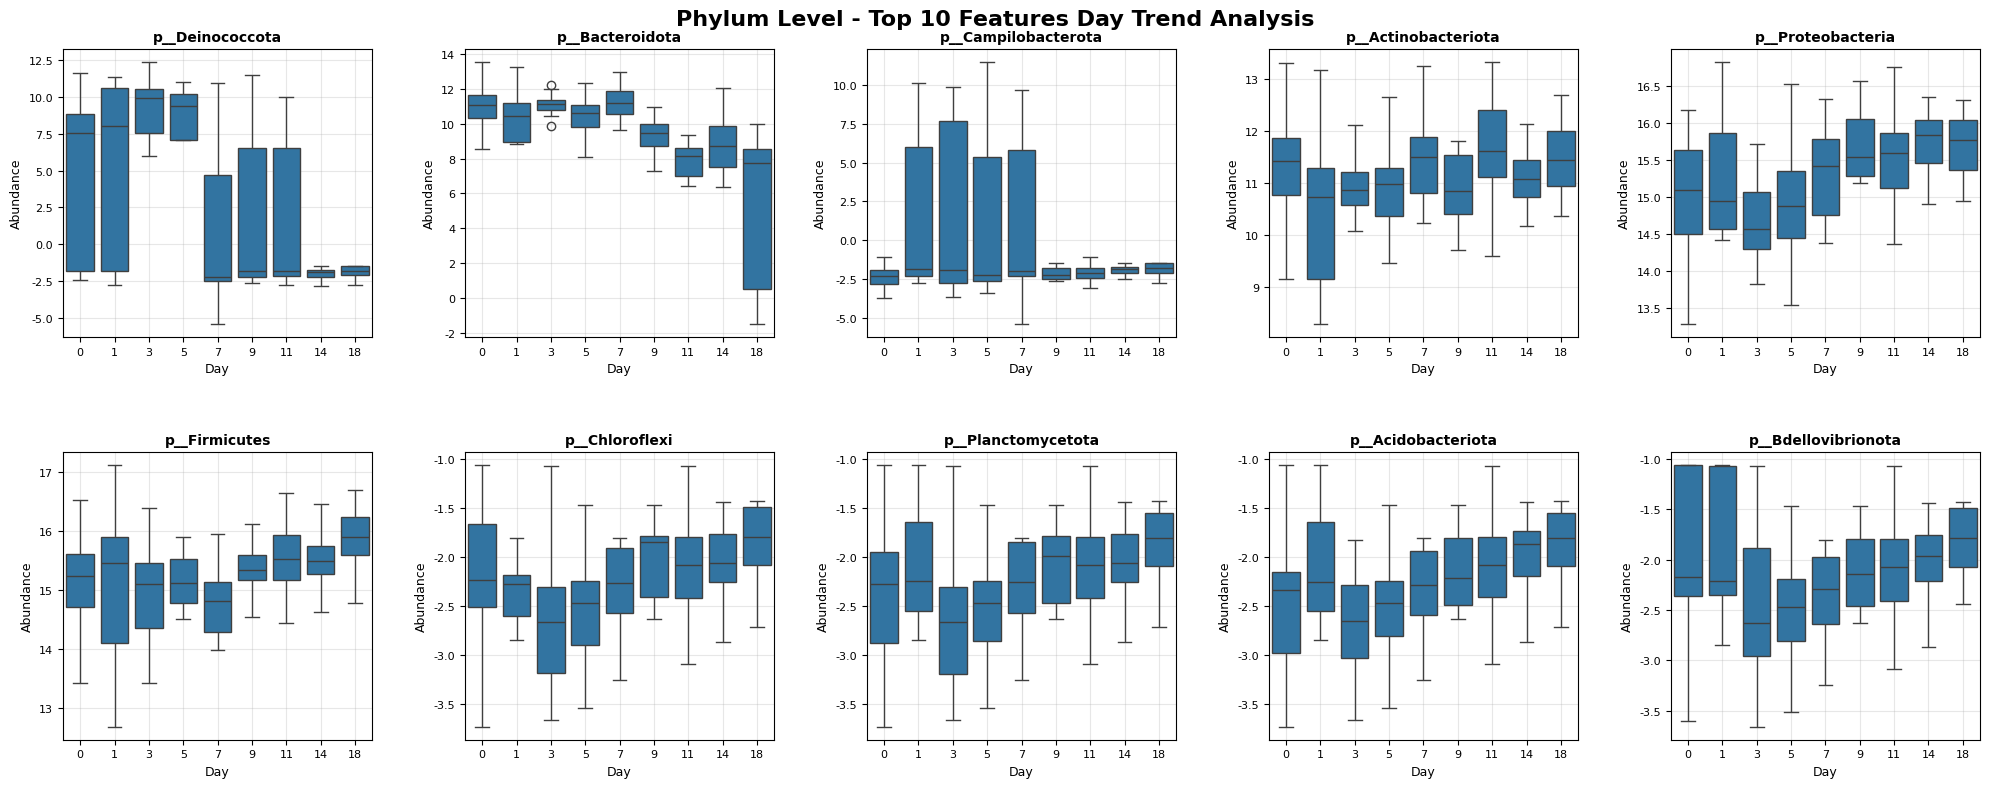

=== Phylum Level Top 10 Features Day Trend 완료 ===
Features: 10개


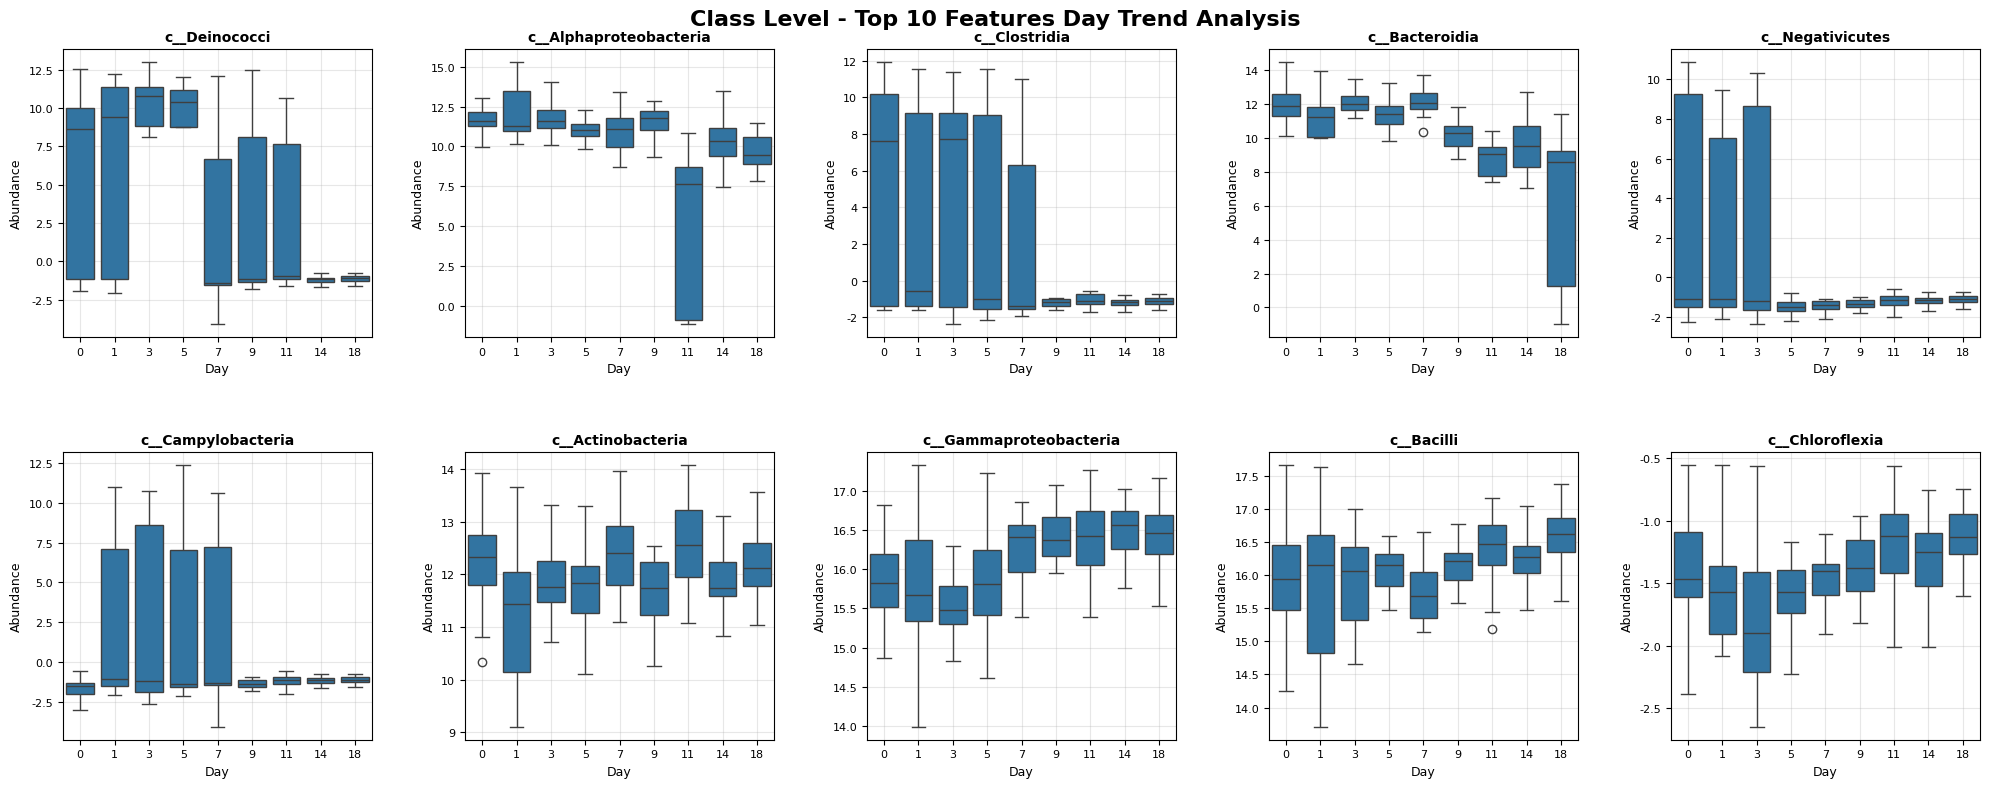

=== Class Level Top 10 Features Day Trend 완료 ===
Features: 10개


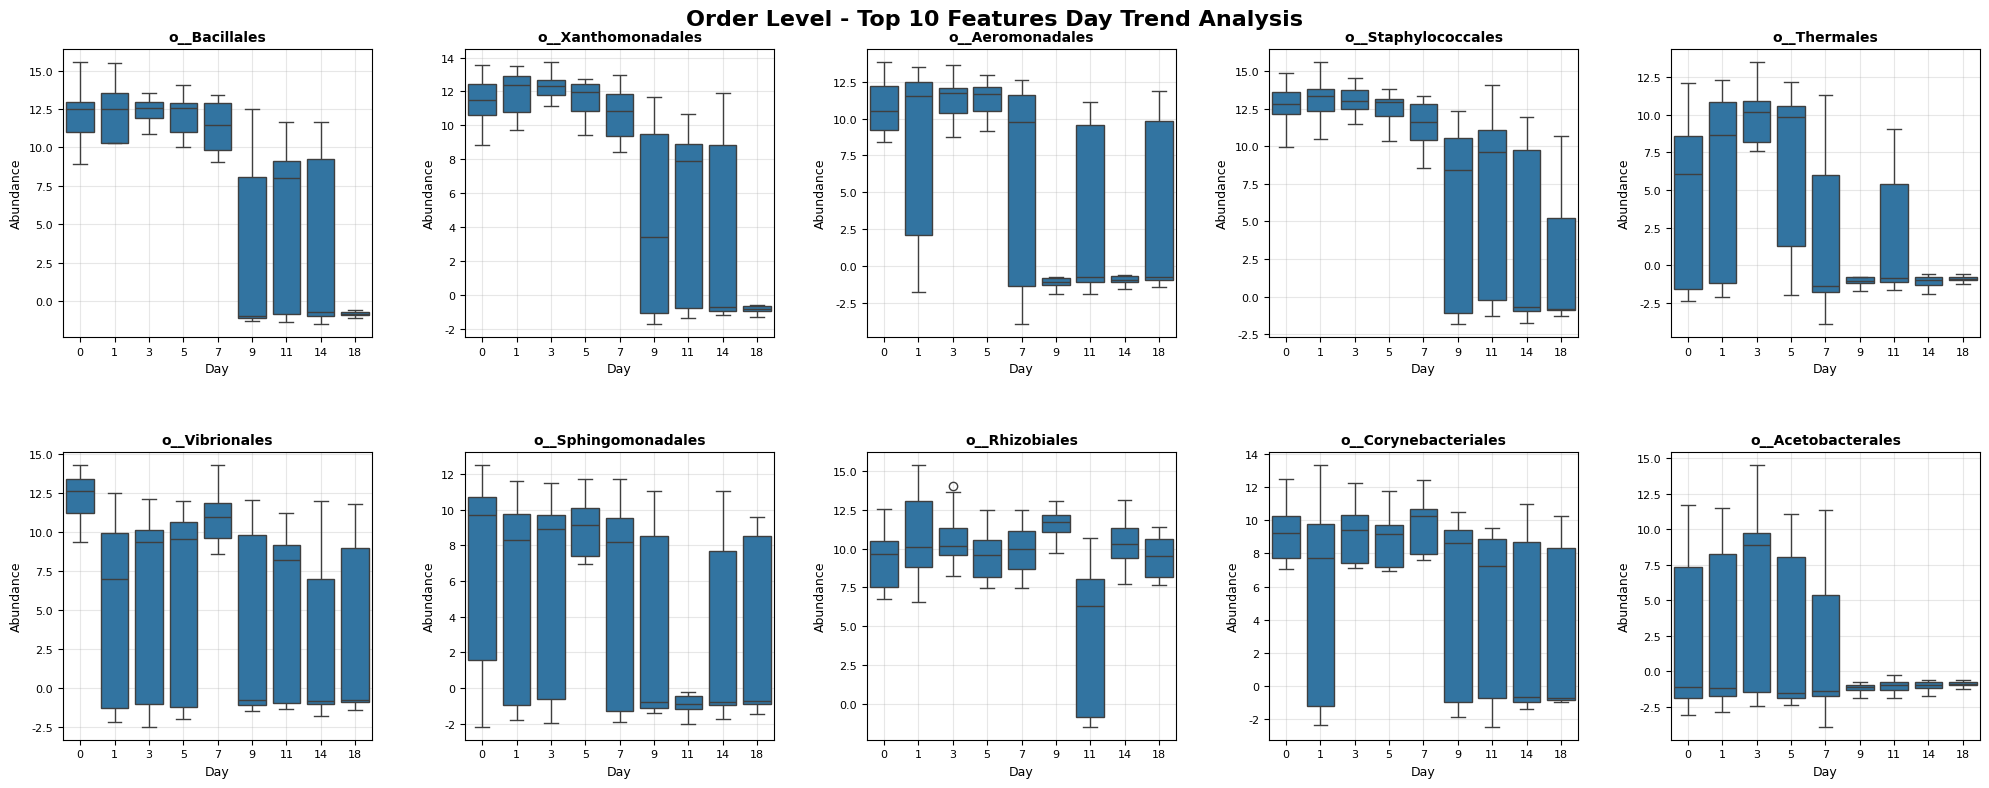

=== Order Level Top 10 Features Day Trend 완료 ===
Features: 10개


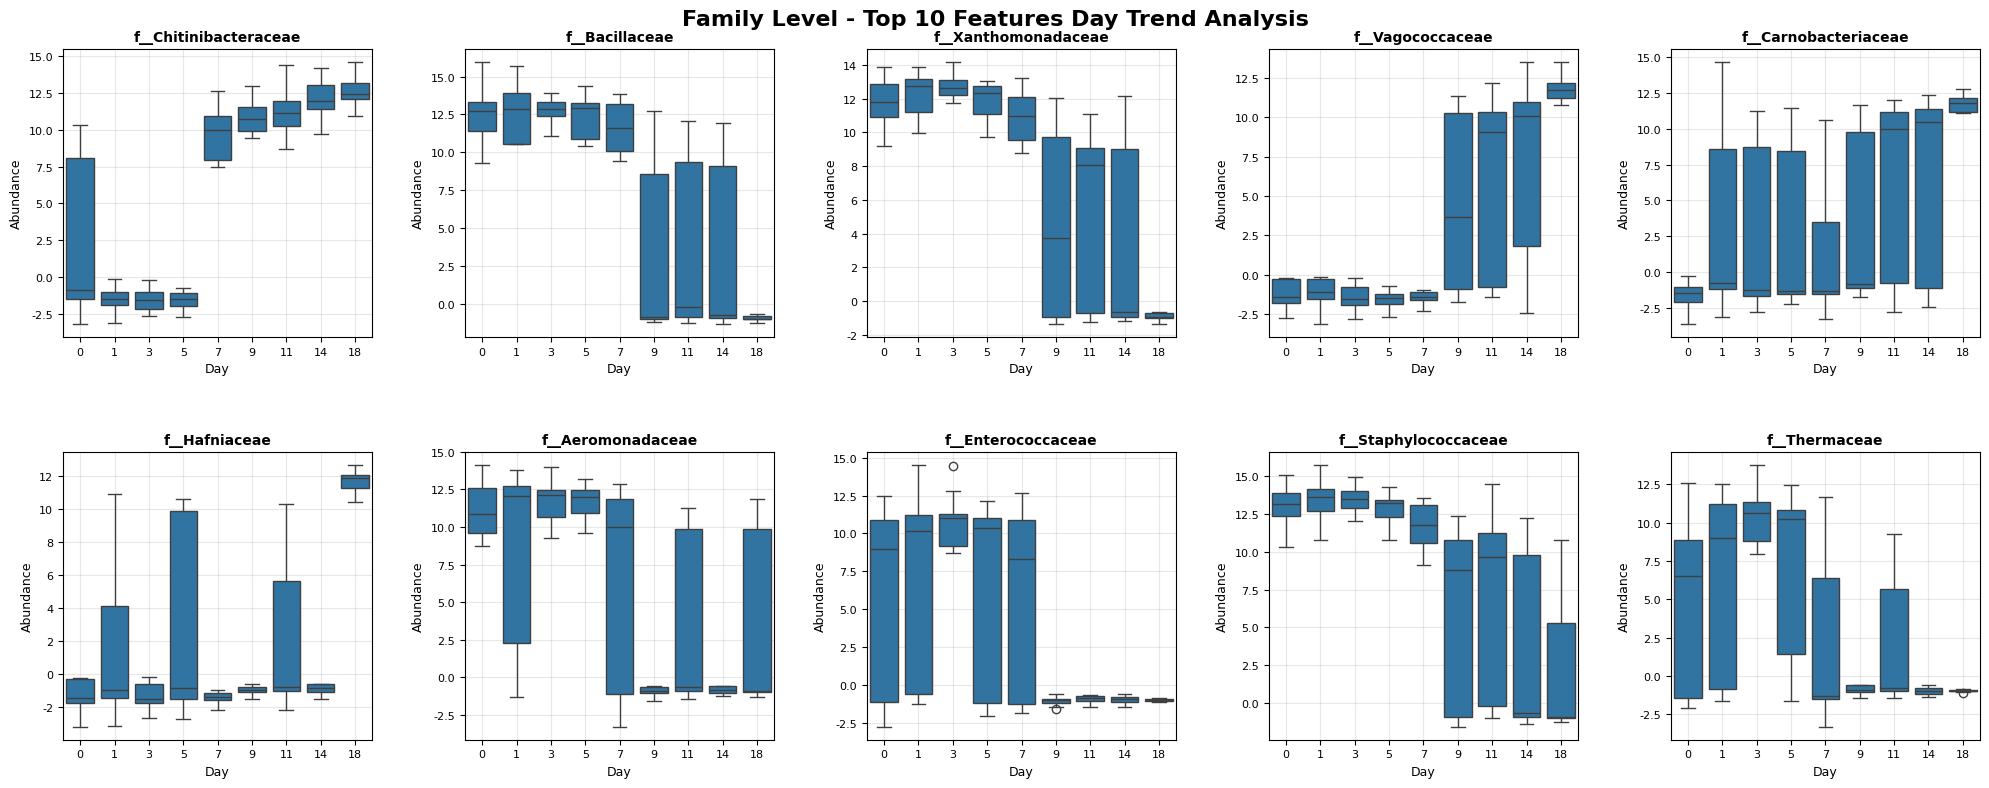

=== Family Level Top 10 Features Day Trend 완료 ===
Features: 10개


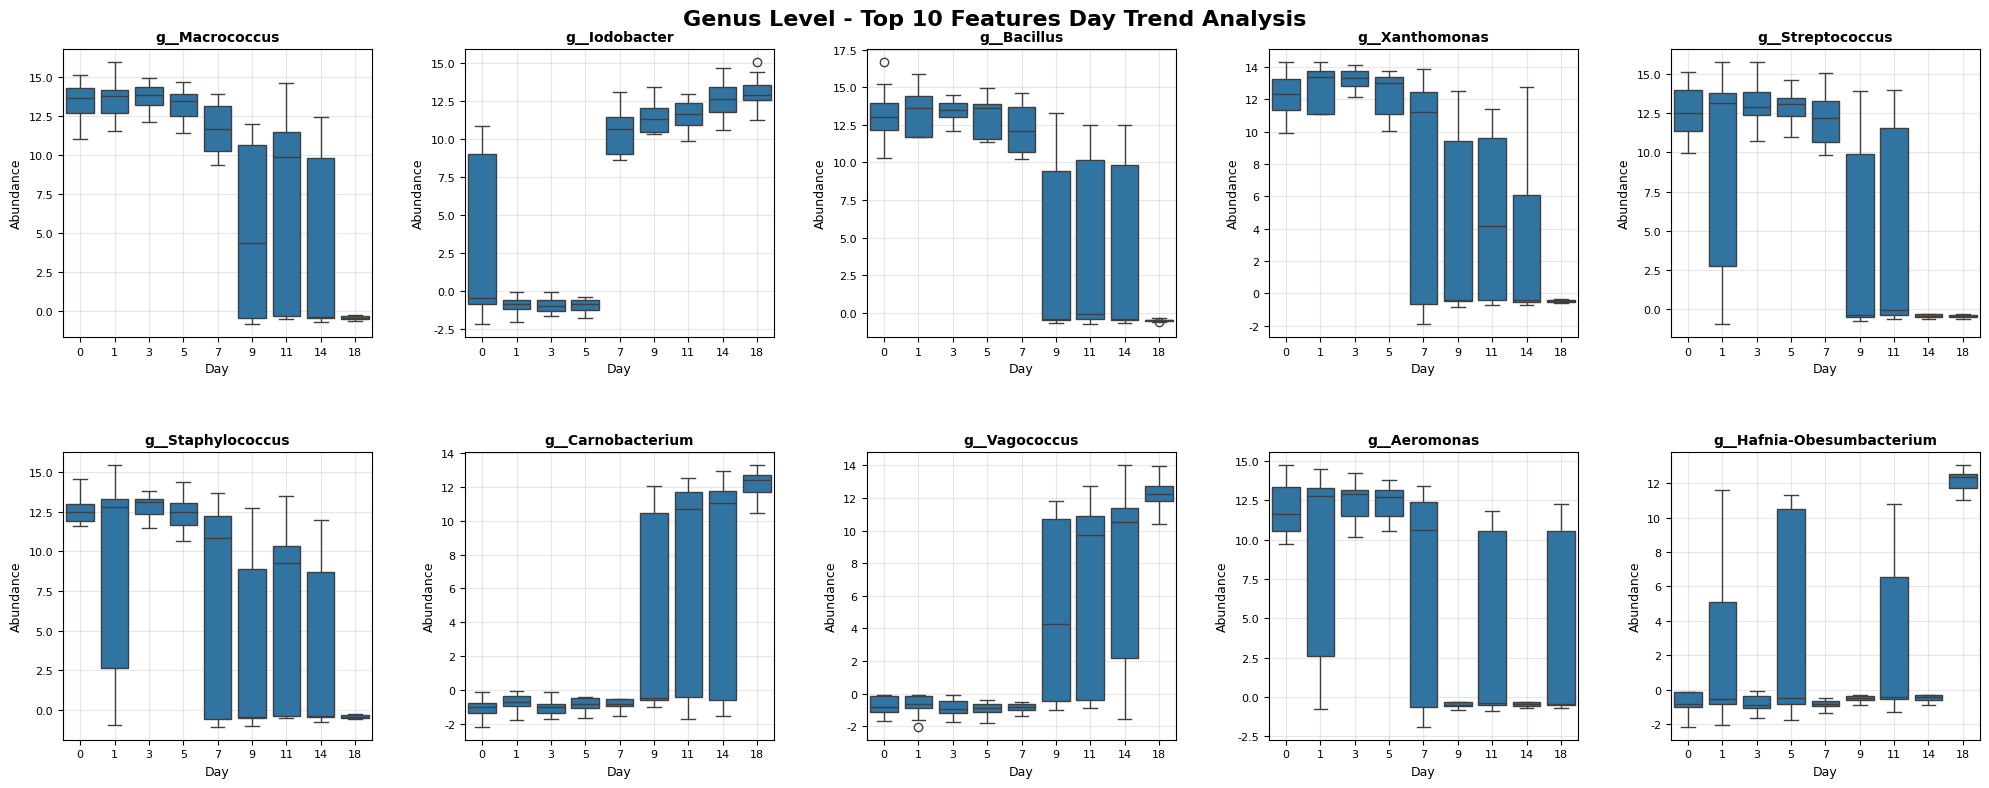

=== Genus Level Top 10 Features Day Trend 완료 ===
Features: 10개
=== 모든 Level Day Trend 분석 완료 ===


In [5]:
# Top 10 Feature BoxPlot 시각화 (Day별 trend 확인)
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정 제거 (기본값 사용)
plt.rcParams['axes.unicode_minus'] = False

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    # 해당 레벨 데이터 추출
    level_data = all_top10_data[level_name]
    top10_data = level_data['top10_data']
    feature_names = level_data['top_10_feature_names']
    
    # Day 컬럼이 없으면 생성 (Description에서 추출)
    if 'Day' not in top10_data.columns:
        top10_data['Day'] = top10_data['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    
    # Figure 생성 (5x2 = 10개 subplot)
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f'{level_name} Level - Top 10 Features Day Trend Analysis', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # subplot을 1차원으로 변환
    axes = axes.flatten()
    
    # 각 Feature별 BoxPlot 생성 (Day별로)
    for i, feature in enumerate(feature_names):
        ax = axes[i]
        
        # Day별 BoxPlot 그리기
        sns.boxplot(data=top10_data, x='Day', y=feature, ax=ax)
        
        ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Day', fontsize=9)
        ax.set_ylabel('Abundance', fontsize=9)
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        
        # Grid 추가
        ax.grid(True, alpha=0.3)
    
    # 레이아웃 조정
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.4, wspace=0.3)
    
    # 자동저장 제거, 출력만
    plt.show()
    
    print(f"=== {level_name} Level Top 10 Features Day Trend 완료 ===")
    print(f"Features: {len(feature_names)}개")

print("=== 모든 Level Day Trend 분석 완료 ===")

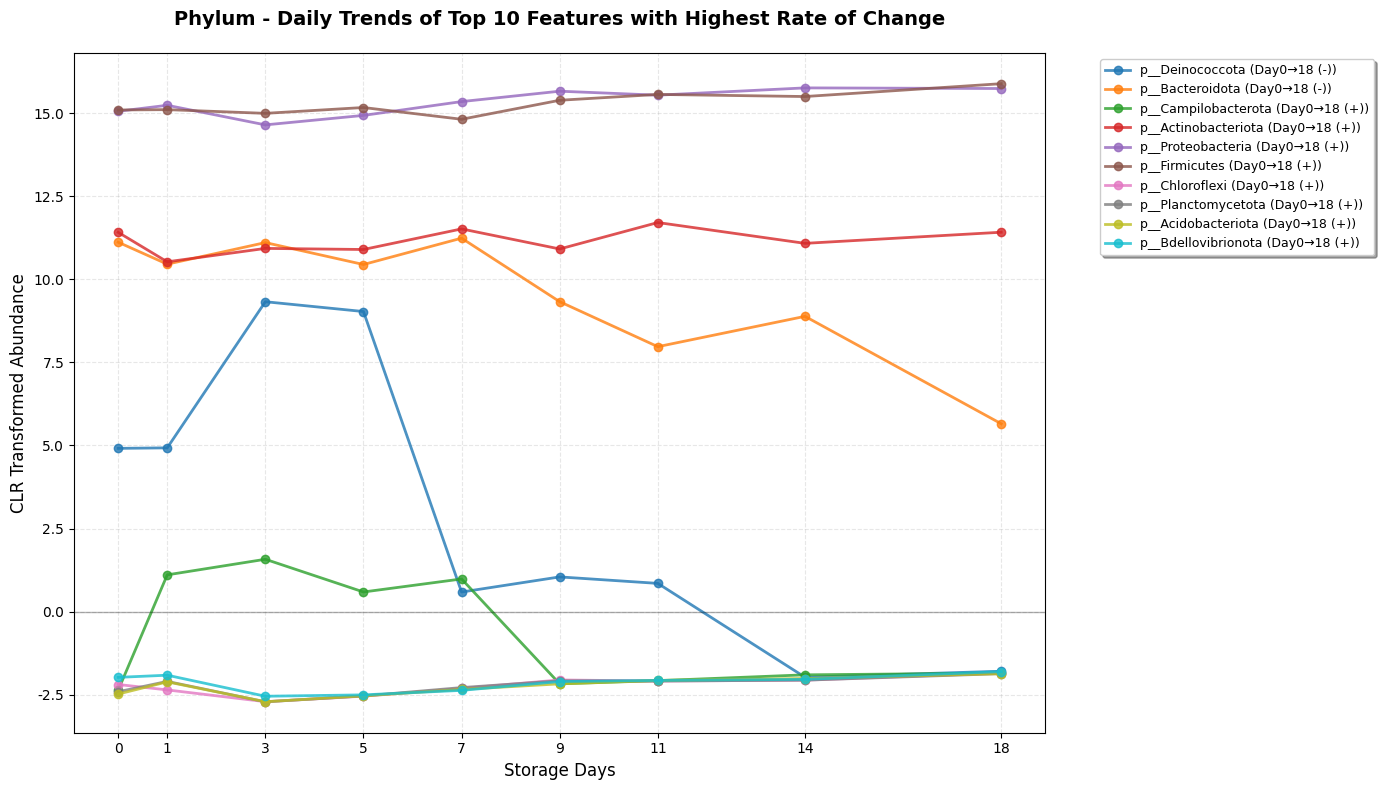

=== Phylum Level Top 10 Features Trend Line Plot 완료 ===
Features: 10개

Phylum 변화 패턴 요약:
  p__Deinococcota: 감소 후 증가 (+11.297) - Day3(9.325) ← Day14(-1.972)
  p__Bacteroidota: 감소 후 증가 (+5.583) - Day7(11.237) ← Day18(5.653)
  p__Campilobacterota: 증가 (+3.939) - Day0(-2.362) → Day3(1.577)
  p__Actinobacteriota: 증가 (+1.182) - Day1(10.525) → Day11(11.707)
  p__Proteobacteria: 증가 (+1.113) - Day3(14.645) → Day14(15.758)
  p__Firmicutes: 증가 (+1.071) - Day7(14.814) → Day18(15.884)
  p__Chloroflexi: 증가 (+0.863) - Day3(-2.708) → Day18(-1.845)
  p__Planctomycetota: 증가 (+0.847) - Day3(-2.712) → Day18(-1.865)
  p__Acidobacteriota: 증가 (+0.845) - Day3(-2.710) → Day18(-1.865)
  p__Bdellovibrionota: 증가 (+0.740) - Day3(-2.544) → Day18(-1.804)




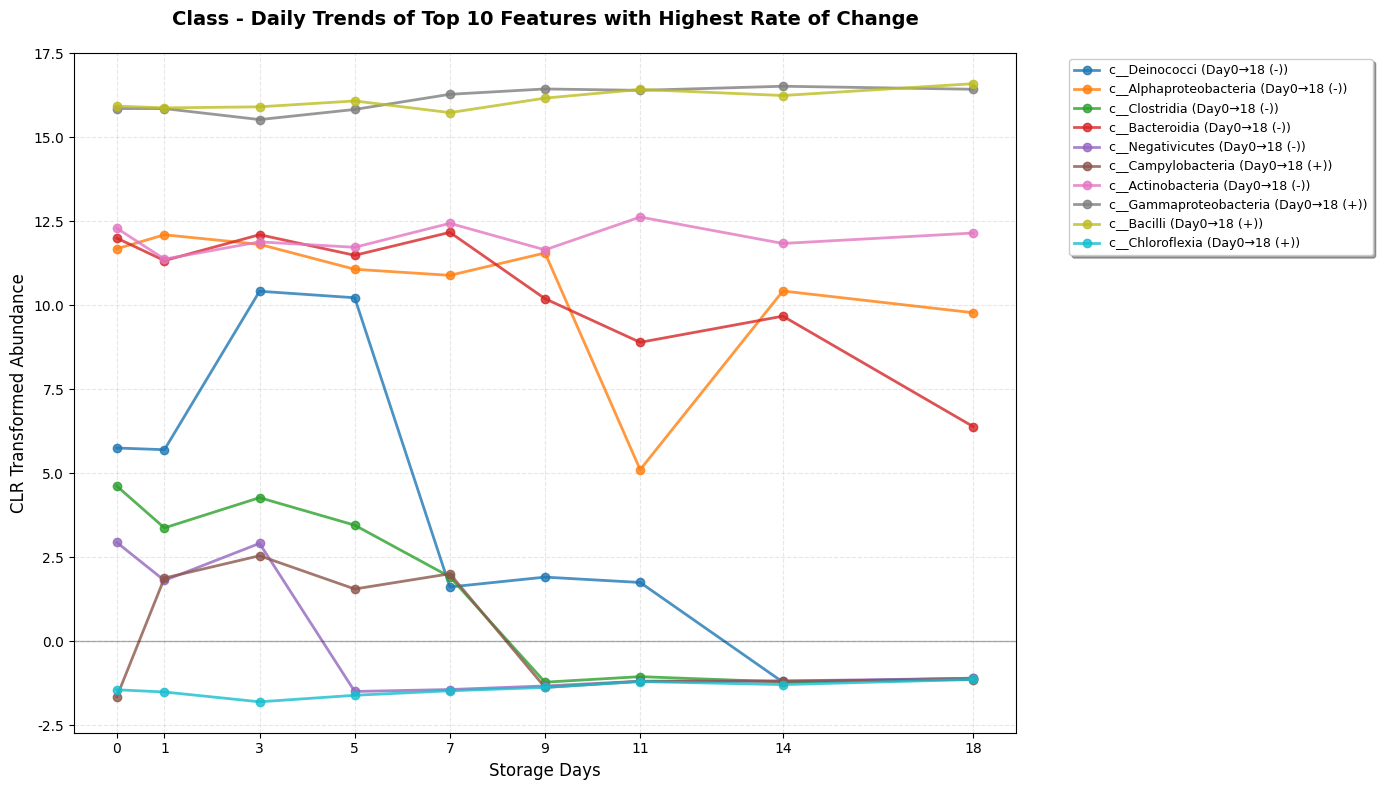

=== Class Level Top 10 Features Trend Line Plot 완료 ===
Features: 10개

Class 변화 패턴 요약:
  c__Deinococci: 감소 후 증가 (+11.635) - Day3(10.417) ← Day14(-1.218)
  c__Alphaproteobacteria: 감소 후 증가 (+6.993) - Day1(12.098) ← Day11(5.105)
  c__Clostridia: 감소 후 증가 (+5.837) - Day0(4.616) ← Day9(-1.221)
  c__Bacteroidia: 감소 후 증가 (+5.783) - Day7(12.171) ← Day18(6.388)
  c__Negativicutes: 감소 후 증가 (+4.435) - Day0(2.938) ← Day5(-1.497)
  c__Campylobacteria: 증가 (+4.196) - Day0(-1.653) → Day3(2.543)
  c__Actinobacteria: 증가 (+1.252) - Day1(11.374) → Day11(12.626)
  c__Gammaproteobacteria: 증가 (+0.993) - Day3(15.528) → Day14(16.520)
  c__Bacilli: 증가 (+0.861) - Day7(15.735) → Day18(16.596)
  c__Chloroflexia: 증가 (+0.666) - Day3(-1.805) → Day18(-1.139)




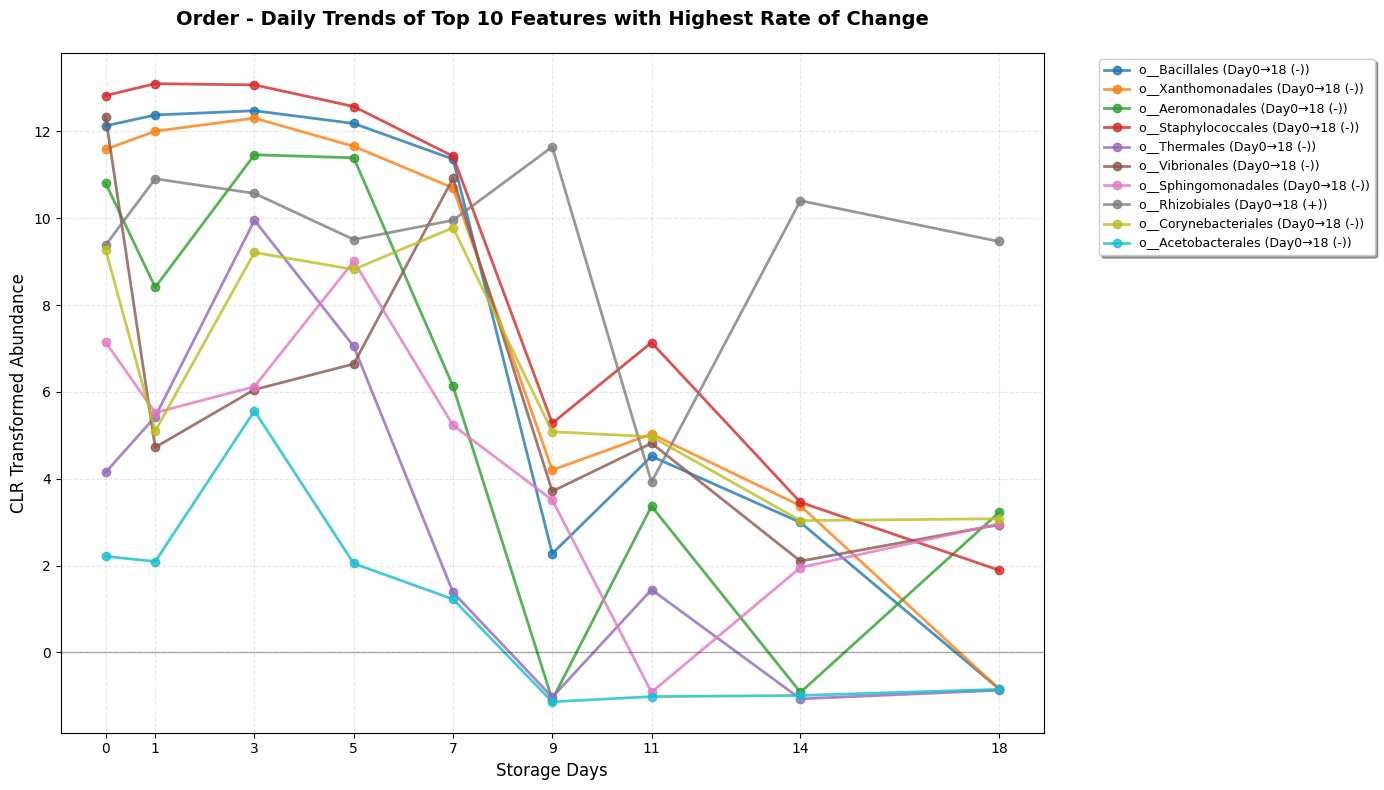

=== Order Level Top 10 Features Trend Line Plot 완료 ===
Features: 10개

Order 변화 패턴 요약:
  o__Bacillales: 감소 후 증가 (+13.314) - Day3(12.478) ← Day18(-0.836)
  o__Xanthomonadales: 감소 후 증가 (+13.143) - Day3(12.308) ← Day18(-0.835)
  o__Aeromonadales: 감소 후 증가 (+12.550) - Day3(11.463) ← Day9(-1.087)
  o__Staphylococcales: 감소 후 증가 (+11.205) - Day1(13.101) ← Day18(1.896)
  o__Thermales: 감소 후 증가 (+11.023) - Day3(9.954) ← Day14(-1.069)
  o__Vibrionales: 감소 후 증가 (+10.241) - Day0(12.344) ← Day14(2.103)
  o__Sphingomonadales: 감소 후 증가 (+9.926) - Day5(9.009) ← Day11(-0.918)
  o__Rhizobiales: 감소 후 증가 (+7.723) - Day9(11.646) ← Day11(3.923)
  o__Corynebacteriales: 감소 후 증가 (+6.745) - Day7(9.783) ← Day14(3.037)
  o__Acetobacterales: 감소 후 증가 (+6.701) - Day3(5.563) ← Day9(-1.137)




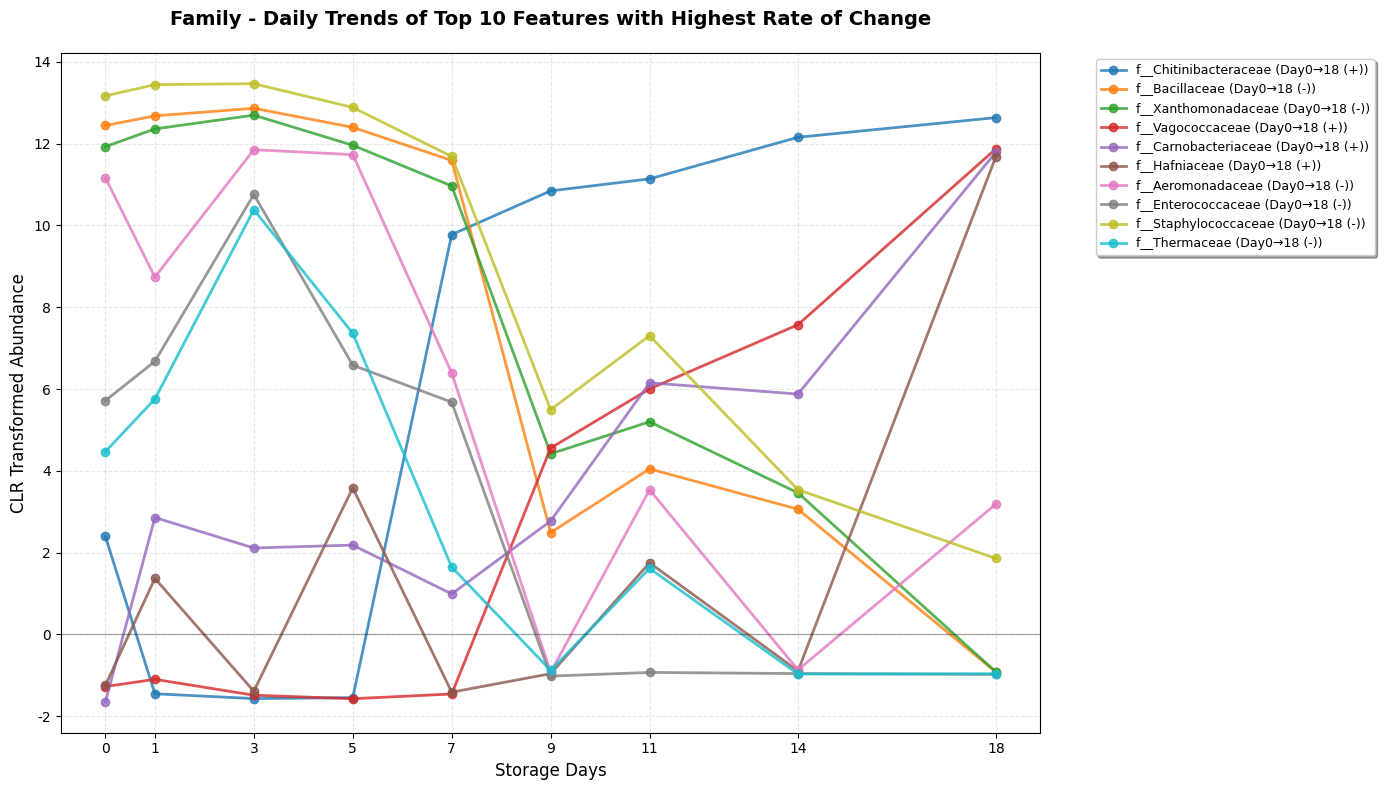

=== Family Level Top 10 Features Trend Line Plot 완료 ===
Features: 10개

Family 변화 패턴 요약:
  f__Chitinibacteraceae: 증가 (+14.204) - Day3(-1.567) → Day18(12.637)
  f__Bacillaceae: 감소 후 증가 (+13.782) - Day3(12.865) ← Day18(-0.917)
  f__Xanthomonadaceae: 감소 후 증가 (+13.614) - Day3(12.697) ← Day18(-0.916)
  f__Vagococcaceae: 증가 (+13.444) - Day5(-1.571) → Day18(11.873)
  f__Carnobacteriaceae: 증가 (+13.439) - Day0(-1.646) → Day18(11.792)
  f__Hafniaceae: 증가 (+13.090) - Day7(-1.411) → Day18(11.679)
  f__Aeromonadaceae: 감소 후 증가 (+12.777) - Day3(11.852) ← Day9(-0.925)
  f__Enterococcaceae: 감소 후 증가 (+11.775) - Day3(10.758) ← Day9(-1.018)
  f__Staphylococcaceae: 감소 후 증가 (+11.607) - Day3(13.466) ← Day18(1.860)
  f__Thermaceae: 감소 후 증가 (+11.351) - Day3(10.386) ← Day14(-0.966)




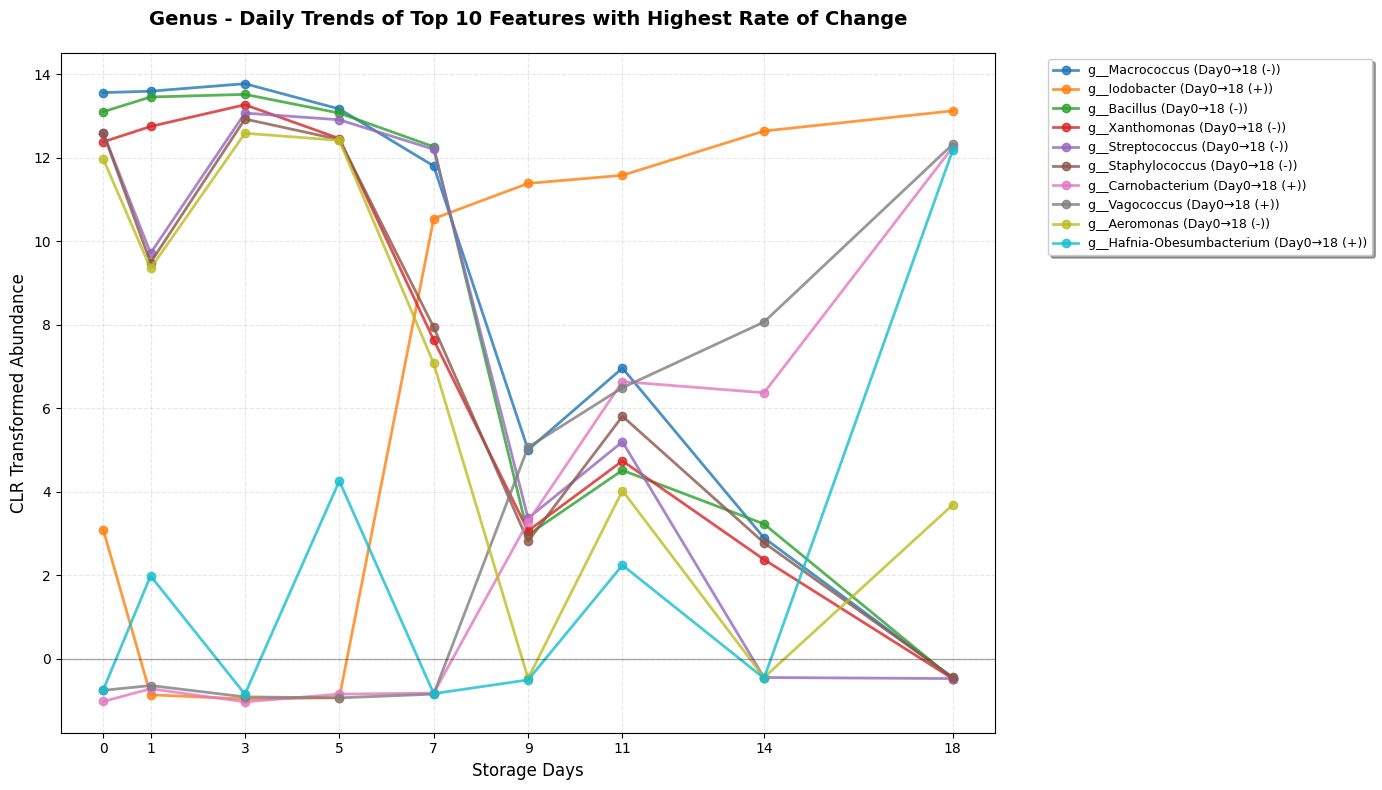

=== Genus Level Top 10 Features Trend Line Plot 완료 ===
Features: 10개

Genus 변화 패턴 요약:
  g__Macrococcus: 감소 후 증가 (+14.234) - Day3(13.776) ← Day18(-0.458)
  g__Iodobacter: 증가 (+14.093) - Day3(-0.967) → Day18(13.126)
  g__Bacillus: 감소 후 증가 (+14.004) - Day3(13.520) ← Day18(-0.484)
  g__Xanthomonas: 감소 후 증가 (+13.753) - Day3(13.272) ← Day18(-0.481)
  g__Streptococcus: 감소 후 증가 (+13.549) - Day3(13.072) ← Day18(-0.478)
  g__Staphylococcus: 감소 후 증가 (+13.381) - Day3(12.929) ← Day18(-0.452)
  g__Carnobacterium: 증가 (+13.290) - Day3(-1.035) → Day18(12.255)
  g__Vagococcus: 증가 (+13.266) - Day5(-0.940) → Day18(12.325)
  g__Aeromonas: 감소 후 증가 (+13.063) - Day3(12.588) ← Day9(-0.475)
  g__Hafnia-Obesumbacterium: 증가 (+13.038) - Day3(-0.852) → Day18(12.185)


=== 모든 Level Trend Line Plot 분석 완료 ===


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['axes.unicode_minus'] = False

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    level_data = all_top10_data[level_name]
    top10_data = level_data['top10_data']
    feature_names = level_data['top_10_feature_names']
    top_10_features = level_data['top_10_features']
    
    plt.figure(figsize=(14, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    # 각 Feature별 Line Plot 생성
    for i, feature in enumerate(feature_names):
        day_means = top10_data.groupby('Day')[feature].mean()
        plt.plot(day_means.index, day_means.values, 
                 marker='o', linewidth=2, markersize=6, 
                 color=colors[i], label=feature, alpha=0.8)
    
    plt.title(f'{level_name} - Daily Trends of Top 10 Features with Highest Rate of Change', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Storage Days', fontsize=12)
    plt.ylabel('CLR Transformed Abundance', fontsize=12)
    
    # 범례 설정 (Feature 이름 + 변화 정보)
    legend_labels = []
    for feature in feature_names:
        feature_info = next(item for item in top_10_features if item['feature'] == feature)
        day_means = top10_data.groupby('Day')[feature].mean()
        first_day = day_means.index.min()
        last_day = day_means.index.max()
        if day_means[last_day] > day_means[first_day]:
            direction = f"(Day{first_day}→{last_day} (+))"
        else:
            direction = f"(Day{first_day}→{last_day} (-))"
        legend_labels.append(f"{feature} {direction}")
    
    plt.legend(legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', 
               fontsize=9, frameon=True, fancybox=True, shadow=True)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(sorted(top10_data['Day'].unique()))
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
    plt.tight_layout()
    plt.show()
    
    print(f"=== {level_name} Level Top 10 Features Trend Line Plot 완료 ===")
    print(f"Features: {len(feature_names)}개")
    print(f"\n{level_name} 변화 패턴 요약:")
    for feature_info in top_10_features:
        feature = feature_info['feature']
        trend = feature_info['trend']
        direction_str = feature_info['direction_str']
        abs_change = feature_info['abs_change']
        print(f"  {feature}: {trend} ({abs_change:+.3f}) - {direction_str}")
    print("\n" + "="*80 + "\n")

print("=== 모든 Level Trend Line Plot 분석 완료 ===")

## 2. PCA 확인 
### - CLR 자체가 Nomalization을 하는 것이기 때문에 정규화 없이 시행

=== Phylum Level PCA 결과 ===
PC1 설명력: 64.14%
PC2 설명력: 21.32%
총 설명력: 85.46%

=== Class Level PCA 결과 ===
PC1 설명력: 47.13%
PC2 설명력: 18.40%
총 설명력: 65.53%

=== Order Level PCA 결과 ===
PC1 설명력: 52.56%
PC2 설명력: 10.68%
총 설명력: 63.24%

=== Family Level PCA 결과 ===
PC1 설명력: 59.32%
PC2 설명력: 13.08%
총 설명력: 72.40%

=== Genus Level PCA 결과 ===
PC1 설명력: 68.14%
PC2 설명력: 9.52%
총 설명력: 77.66%



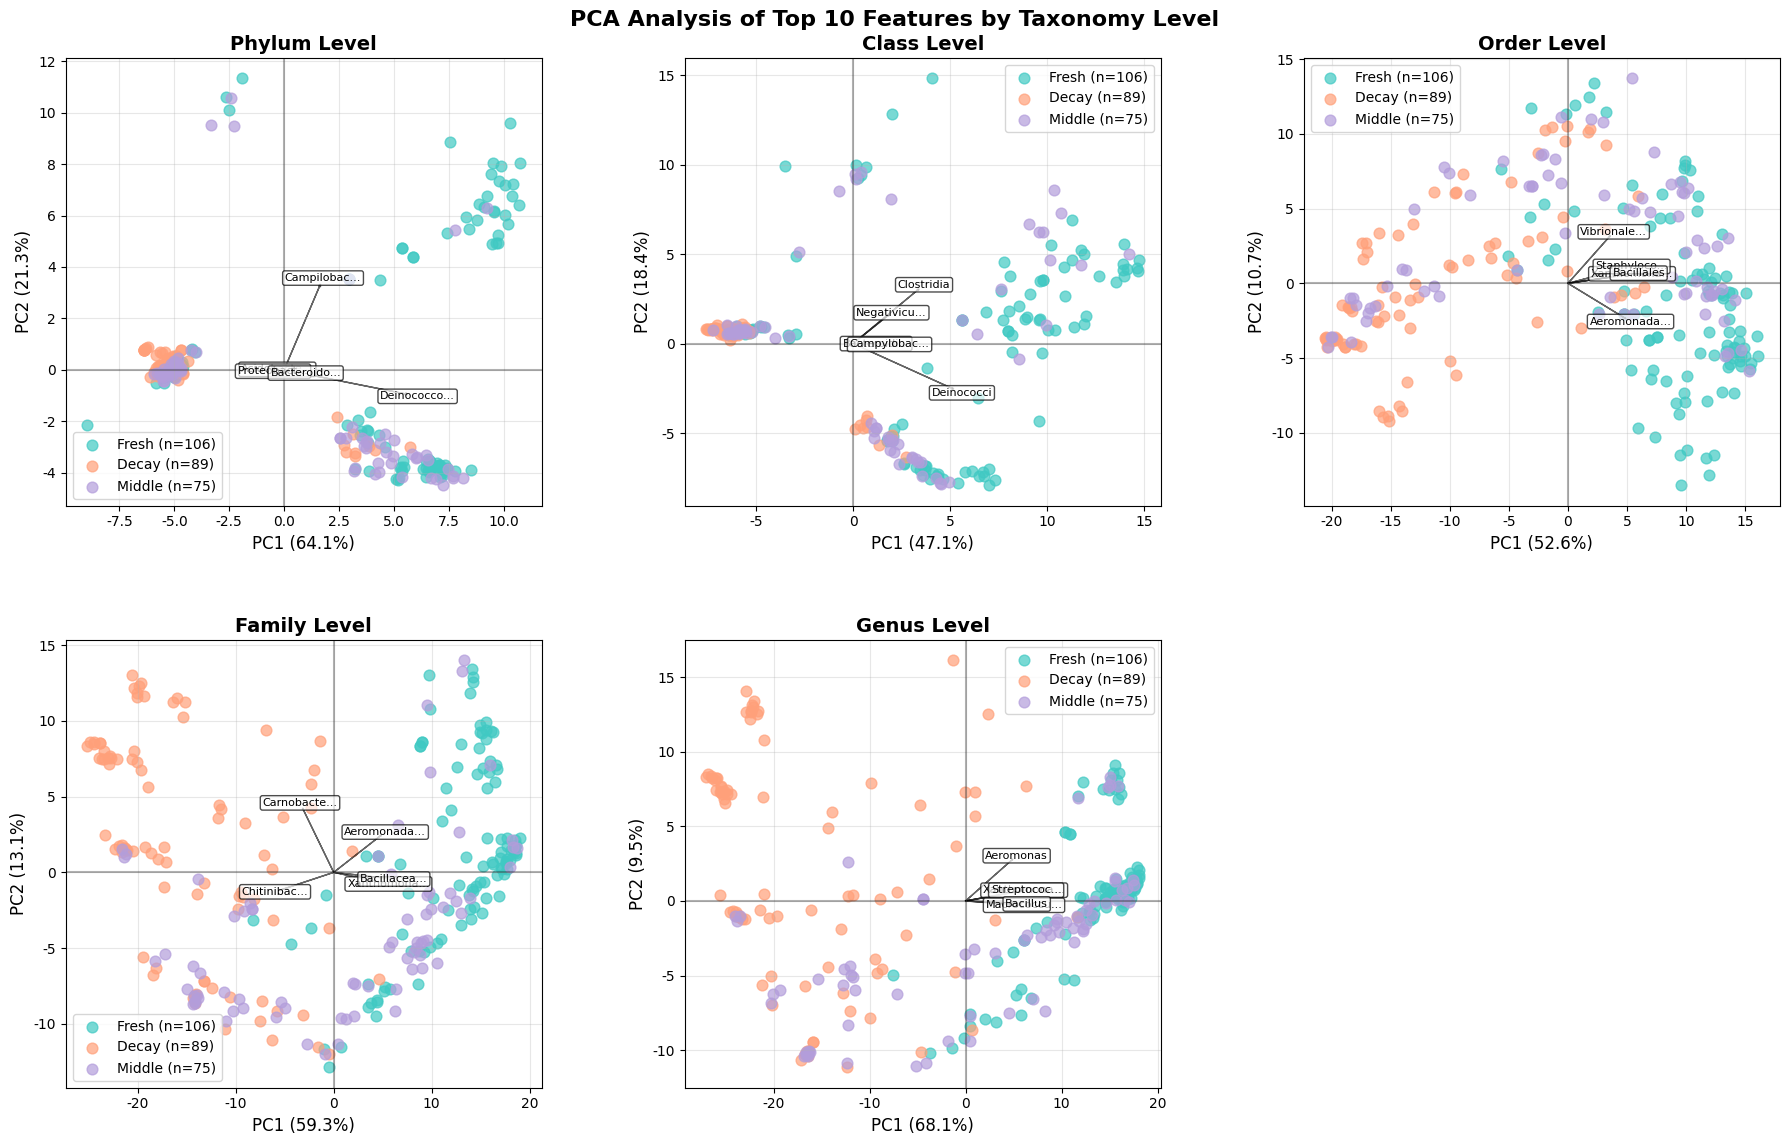

=== 모든 Level PCA 분석 완료 ===

=== PCA 설명력 요약 ===
Phylum  : PC1= 64.1%, PC2= 21.3%, Total= 85.5%
Class   : PC1= 47.1%, PC2= 18.4%, Total= 65.5%
Order   : PC1= 52.6%, PC2= 10.7%, Total= 63.2%
Family  : PC1= 59.3%, PC2= 13.1%, Total= 72.4%
Genus   : PC1= 68.1%, PC2=  9.5%, Total= 77.7%


In [7]:
# Top 10 Feature PCA 분석 (모든 taxonomy level)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 색상 및 라벨 설정
colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 1: "Decay", 2: "Middle"}

# 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

# 모든 레벨 PCA 결과 저장
all_pca_results = {}

# Figure 생성 (3x2 = 6개 subplot, 하나는 빈 공간)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('PCA Analysis of Top 10 Features by Taxonomy Level', 
             fontsize=16, fontweight='bold', y=0.95)

# 축을 1차원으로 변환
axes = axes.flatten()

level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

for idx, level_name in enumerate(level_names):
    # 해당 레벨 데이터 추출
    level_data = all_top10_data[level_name]
    X_top10 = level_data['X_top10']
    y_top10 = level_data['y_top10']
    feature_names = level_data['top_10_feature_names']
    
    # PCA 수행 (정규화 없이)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_top10)
    
    # 설명 분산비
    explained_variance = pca.explained_variance_ratio_
    pc1_var = explained_variance[0] * 100
    pc2_var = explained_variance[1] * 100
    
    # PCA 결과 저장
    all_pca_results[level_name] = {
        'pca': pca,
        'X_pca': X_pca,
        'explained_variance': explained_variance,
        'pc1_var': pc1_var,
        'pc2_var': pc2_var
    }
    
    # 현재 subplot 선택
    ax = axes[idx]
    
    # 각 라벨별로 scatter plot
    for label in [0, 1, 2]:
        mask = y_top10 == label
        if np.sum(mask) > 0:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                      c=colors[label], alpha=0.7, s=60,
                      label=f'{label_names[label]} (n={np.sum(mask)})')
    
    # Feature loading vectors (주성분 기여도 벡터)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    # 벡터 그리기 (상위 5개만 표시해서 가독성 향상)
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_loading_indices = np.argsort(loading_magnitudes)[-5:]
    
    for i in top_loading_indices:
        ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
                head_width=0.1, head_length=0.1, fc='black', ec='black', alpha=0.6)
        
        # Feature 이름 축약
        feature_short = feature_names[i].replace('g__', '').replace('f__', '').replace('o__', '').replace('c__', '').replace('p__', '')
        if len(feature_short) > 10:
            feature_short = feature_short[:10] + '...'
            
        ax.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, feature_short,
               fontsize=8, ha='center', va='center', 
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    
    # 축 라벨 및 제목
    ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)', fontsize=12)
    ax.set_title(f'{level_name} Level', fontsize=14, fontweight='bold')
    
    # 격자 및 중심선
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # 범례
    ax.legend(fontsize=10, loc='best')
    
    print(f"=== {level_name} Level PCA 결과 ===")
    print(f"PC1 설명력: {pc1_var:.2f}%")
    print(f"PC2 설명력: {pc2_var:.2f}%")
    print(f"총 설명력: {pc1_var + pc2_var:.2f}%")
    print()

# 마지막 subplot 제거 (6개 중 5개만 사용)
fig.delaxes(axes[5])

# 레이아웃 조정
plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.3, wspace=0.3)

# 출력
plt.show()

print("=== 모든 Level PCA 분석 완료 ===")
print("\n=== PCA 설명력 요약 ===")
for level_name, results in all_pca_results.items():
    pc1_var = results['pc1_var']
    pc2_var = results['pc2_var']
    total_var = pc1_var + pc2_var
    print(f"{level_name:8s}: PC1={pc1_var:5.1f}%, PC2={pc2_var:5.1f}%, Total={total_var:5.1f}%")

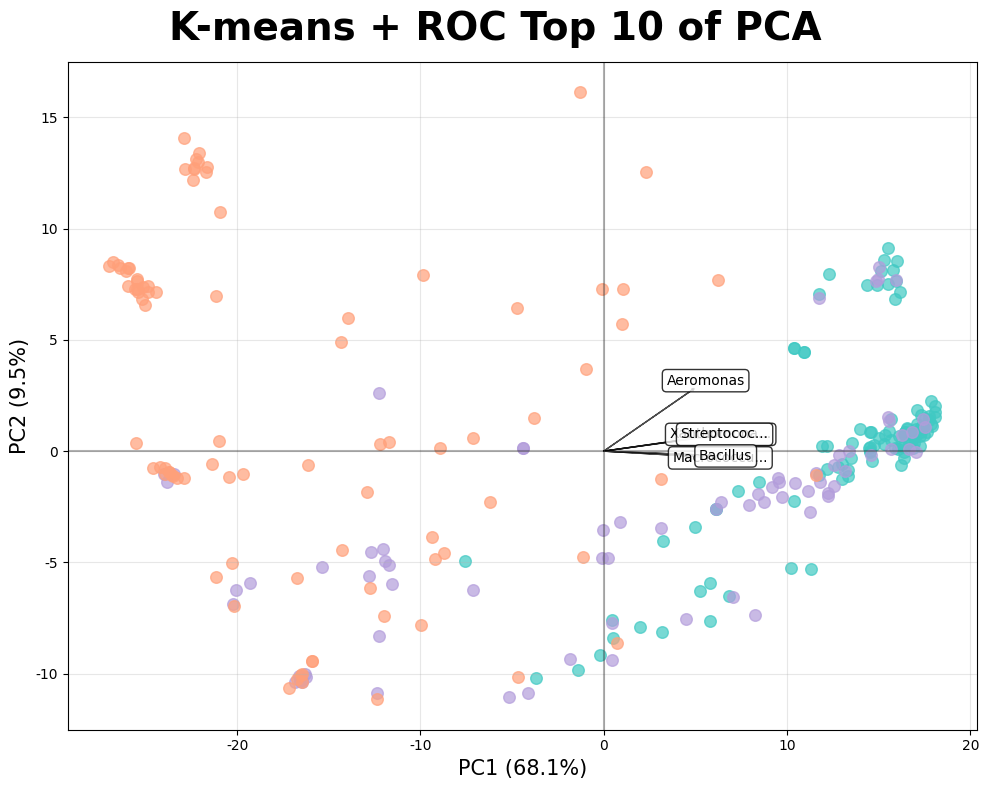

In [8]:
# Genus Level만 PCA 단독 시각화 (K-means + ROC Top 10 of PCA)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 색상 및 라벨 설정
colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 2: "Middle", 1: "Spoilage"}  # Decay → Spoilage, 순서 Fresh-Middle-Spoilage

level_name = 'Genus'
level_data = all_top10_data[level_name]
X_top10 = level_data['X_top10']
y_top10 = level_data['y_top10']
feature_names = level_data['top_10_feature_names']

# PCA 수행
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_top10)
explained_variance = pca.explained_variance_ratio_
pc1_var = explained_variance[0] * 100
pc2_var = explained_variance[1] * 100

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
fig.suptitle('K-means + ROC Top 10 of PCA', fontsize=28, fontweight='bold', y=0.98)

# 각 라벨별로 scatter plot (Fresh, Middle, Spoilage 순서)
for label in [0, 2, 1]:
    mask = y_top10 == label
    if np.sum(mask) > 0:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[label], alpha=0.7, s=70,
                   label=f'{label_names[label]} (n={np.sum(mask)})')

# Feature loading vectors (상위 5개만)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_loading_indices = np.argsort(loading_magnitudes)[-5:]

for i in top_loading_indices:
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.12, head_length=0.12, fc='black', ec='black', alpha=0.7)
    feature_short = feature_names[i].replace('g__', '').replace('f__', '').replace('o__', '').replace('c__', '').replace('p__', '')
    if len(feature_short) > 10:
        feature_short = feature_short[:10] + '...'
    ax.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature_short,
            fontsize=10, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# 축 라벨 및 제목
ax.set_xlabel(f'PC1 ({pc1_var:.1f}%)', fontsize=15)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}%)', fontsize=15)

# 격자 및 중심선
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)


plt.tight_layout()
plt.show()

## 2-1. Feature Importance 확인

=== PCA Feature Importance 분석 ===

=== Phylum Level PCA Feature Importance ===

Phylum Level - Top 5 Most Important Features:
--------------------------------------------------------------------------------
 3. p__Campilobacterota
    Total Importance: 1.2328
    PC1: 0.2738 (positive)
    PC2: 0.9589 (positive)

 1. p__Deinococcota
    Total Importance: 1.2186
    PC1: 0.9406 (positive)
    PC2: 0.2780 (negative)

 2. p__Bacteroidota
    Total Importance: 0.1866
    PC1: 0.1517 (positive)
    PC2: 0.0349 (negative)

 5. p__Proteobacteria
    Total Importance: 0.0940
    PC1: 0.0788 (negative)
    PC2: 0.0152 (negative)

 4. p__Actinobacteriota
    Total Importance: 0.0742
    PC1: 0.0449 (negative)
    PC2: 0.0293 (negative)

=== Class Level PCA Feature Importance ===

Class Level - Top 5 Most Important Features:
--------------------------------------------------------------------------------
 1. c__Deinococci
    Total Importance: 1.3522
    PC1: 0.7576 (positive)
    PC2: 0.5946 (ne

/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/3759389540.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/3759389540.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/3759389540.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/3759389540.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

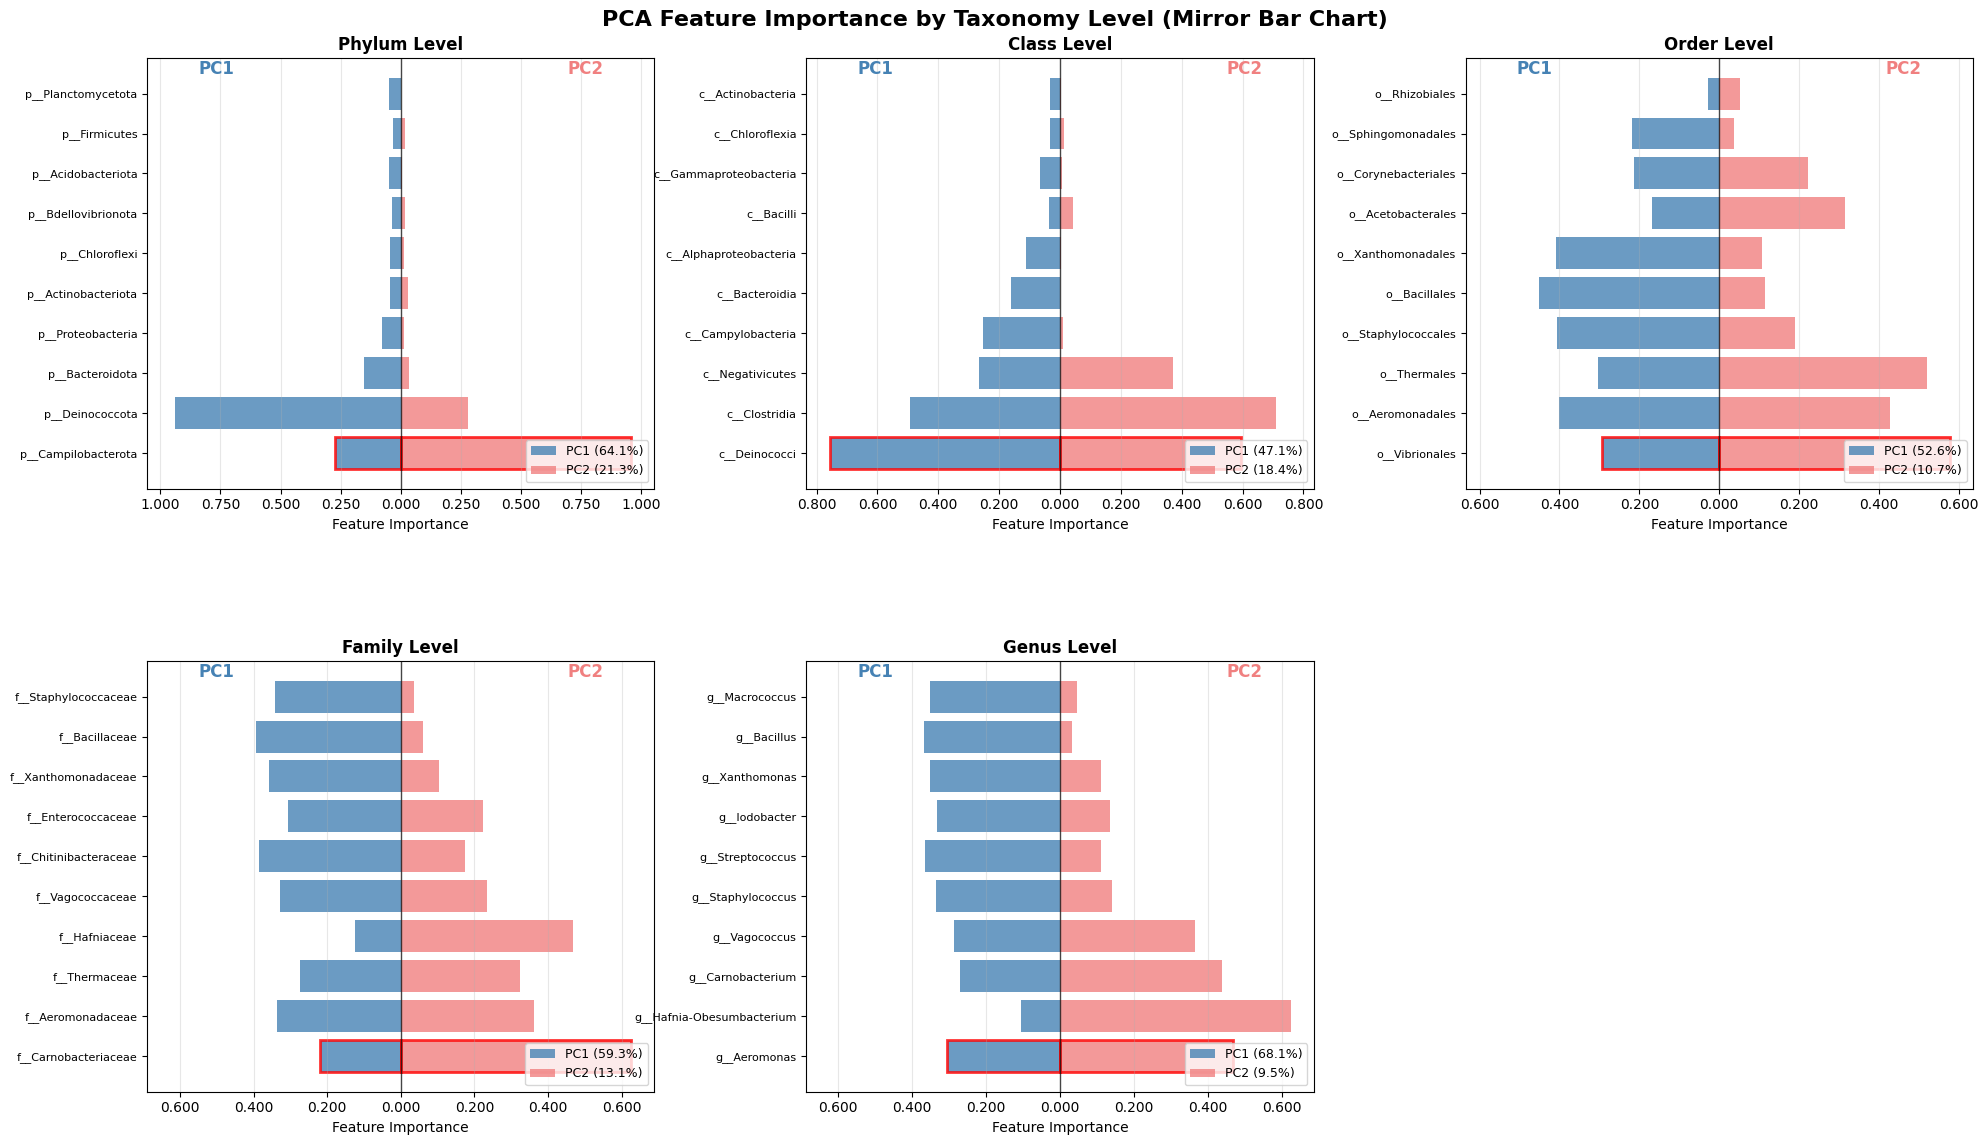


=== 각 Taxonomy Level별 가장 중요한 Feature 요약 ===
Phylum  : p__Campilobacterota
           Total Importance: 1.2328
           PC1: 0.2738, PC2: 0.9589

Class   : c__Deinococci
           Total Importance: 1.3522
           PC1: 0.7576, PC2: 0.5946

Order   : o__Vibrionales
           Total Importance: 0.8701
           PC1: 0.2929, PC2: 0.5772

Family  : f__Carnobacteriaceae
           Total Importance: 0.8467
           PC1: 0.2206, PC2: 0.6261

Genus   : g__Aeromonas
           Total Importance: 0.7752
           PC1: 0.3070, PC2: 0.4682



/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/3759389540.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])


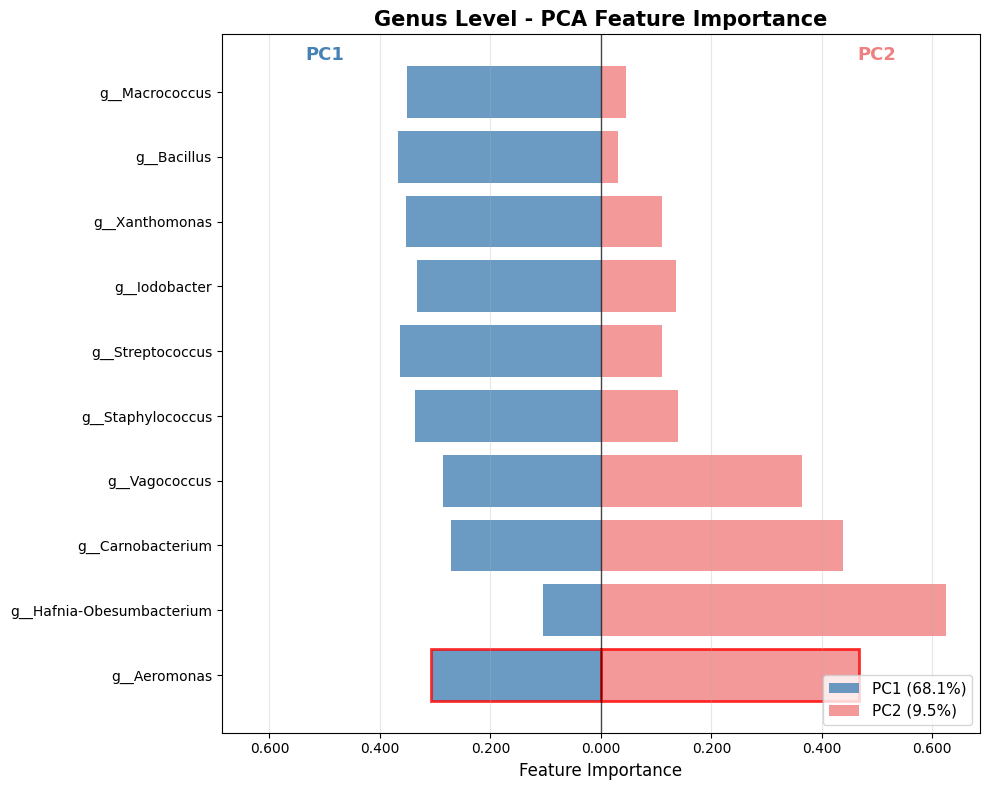

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== PCA Feature Importance 분석 ===\n")

# 모든 레벨의 Feature Importance 결과 저장
all_feature_importance = {}

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    print(f"{'='*60}")
    print(f"=== {level_name} Level PCA Feature Importance ===")
    print(f"{'='*60}")
    
    # PCA 결과 가져오기
    pca_results = all_pca_results[level_name]
    pca = pca_results['pca']
    feature_names = all_top10_data[level_name]['top_10_feature_names']
    
    # PC1, PC2에 대한 Feature Importance (절댓값)
    pc1_importance = np.abs(pca.components_[0])
    pc2_importance = np.abs(pca.components_[1])
    
    # 전체 Importance (PC1 + PC2)
    total_importance = pc1_importance + pc2_importance
    
    # DataFrame 생성 (feature 이름 축약 없이 원본 사용)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'PC1_Importance': pc1_importance,
        'PC2_Importance': pc2_importance,
        'Total_Importance': total_importance,
        'PC1_Direction': pca.components_[0],  # 방향성 포함
        'PC2_Direction': pca.components_[1]   # 방향성 포함
    })
    
    # Total Importance로 정렬
    importance_df = importance_df.sort_values('Total_Importance', ascending=False)
    
    # 결과 저장
    all_feature_importance[level_name] = importance_df
    
    # 상위 5개 Feature 출력
    print(f"\n{level_name} Level - Top 5 Most Important Features:")
    print("-" * 80)
    for i, row in importance_df.head(5).iterrows():
        print(f"{row.name+1:2d}. {row['Feature']}")
        print(f"    Total Importance: {row['Total_Importance']:.4f}")
        print(f"    PC1: {row['PC1_Importance']:.4f} ({'positive' if row['PC1_Direction'] > 0 else 'negative'})")
        print(f"    PC2: {row['PC2_Importance']:.4f} ({'positive' if row['PC2_Direction'] > 0 else 'negative'})")
        print()

print("\n" + "="*80)
print("=== 모든 Level Feature Importance 분석 완료 ===")

# Feature Importance 시각화 - 좌우 대칭 바 그래프
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('PCA Feature Importance by Taxonomy Level (Mirror Bar Chart)', 
             fontsize=16, fontweight='bold', y=0.95)

axes = axes.flatten()

for idx, level_name in enumerate(['Phylum', 'Class', 'Order', 'Family', 'Genus']):
    ax = axes[idx]
    importance_df = all_feature_importance[level_name]
    
    # Y축 위치 설정
    y_pos = np.arange(len(importance_df))
    
    # PC1은 왼쪽 (음수값), PC2는 오른쪽 (양수값)
    pc1_values = -importance_df['PC1_Importance']  # 왼쪽으로 표시하기 위해 음수
    pc2_values = importance_df['PC2_Importance']   # 오른쪽으로 표시
    
    # 좌우 대칭 바 그래프 그리기
    bars1 = ax.barh(y_pos, pc1_values, height=0.8,
                    label=f"PC1 ({all_pca_results[level_name]['pc1_var']:.1f}%)", 
                    alpha=0.8, color='steelblue')
    bars2 = ax.barh(y_pos, pc2_values, height=0.8,
                    label=f"PC2 ({all_pca_results[level_name]['pc2_var']:.1f}%)", 
                    alpha=0.8, color='lightcoral')
    
    # Y축 라벨 설정 (Feature 이름, 원본 그대로)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(importance_df['Feature'], fontsize=8)
    
    # 축 라벨 및 제목
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(f'{level_name} Level', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    
    # 중앙 축 (x=0) 강조
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    
    # Grid 추가
    ax.grid(True, alpha=0.3, axis='x')
    
    # X축 범위 대칭으로 설정
    max_val = max(importance_df['PC1_Importance'].max(), 
                  importance_df['PC2_Importance'].max())
    ax.set_xlim(-max_val*1.1, max_val*1.1)
    
    # 가장 중요한 Feature 강조 (첫 번째)
    bars1[0].set_edgecolor('red')
    bars1[0].set_linewidth(2)
    bars2[0].set_edgecolor('red') 
    bars2[0].set_linewidth(2)
    
    # X축 틱 라벨을 절댓값으로 표시
    ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
    
    # PC1/PC2 영역 라벨 추가
    ax.text(-max_val*0.8, len(importance_df)*0.95, 'PC1', 
            fontsize=12, fontweight='bold', ha='center', color='steelblue')
    ax.text(max_val*0.8, len(importance_df)*0.95, 'PC2', 
            fontsize=12, fontweight='bold', ha='center', color='lightcoral')

# 마지막 subplot 제거
fig.delaxes(axes[5])

plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.4, wspace=0.3)
plt.show()

# 레벨별 가장 중요한 Feature 요약
print("\n" + "="*80)
print("=== 각 Taxonomy Level별 가장 중요한 Feature 요약 ===")
print("="*80)

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    importance_df = all_feature_importance[level_name]
    top_feature = importance_df.iloc[0]
    
    print(f"{level_name:8s}: {top_feature['Feature']}")
    print(f"           Total Importance: {top_feature['Total_Importance']:.4f}")
    print(f"           PC1: {top_feature['PC1_Importance']:.4f}, PC2: {top_feature['PC2_Importance']:.4f}")
    print()
    
    
# Genus Level Feature Importance 시각화
    genus_df = all_feature_importance['Genus']
max_val = max(genus_df['PC1_Importance'].max(), genus_df['PC2_Importance'].max())
y_pos = np.arange(len(genus_df))

fig, ax = plt.subplots(figsize=(10, 8))
pc1_values = -genus_df['PC1_Importance']
pc2_values = genus_df['PC2_Importance']

bars1 = ax.barh(y_pos, pc1_values, height=0.8,
                label=f"PC1 ({all_pca_results['Genus']['pc1_var']:.1f}%)",
                alpha=0.8, color='steelblue')
bars2 = ax.barh(y_pos, pc2_values, height=0.8,
                label=f"PC2 ({all_pca_results['Genus']['pc2_var']:.1f}%)",
                alpha=0.8, color='lightcoral')

ax.set_yticks(y_pos)
ax.set_yticklabels(genus_df['Feature'], fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Genus Level - PCA Feature Importance', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(-max_val*1.1, max_val*1.1)

bars1[0].set_edgecolor('red')
bars1[0].set_linewidth(2)
bars2[0].set_edgecolor('red')
bars2[0].set_linewidth(2)

ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
ax.text(-max_val*0.8, len(genus_df)*0.95, 'PC1',
        fontsize=13, fontweight='bold', ha='center', color='steelblue')
ax.text(max_val*0.8, len(genus_df)*0.95, 'PC2',
        fontsize=13, fontweight='bold', ha='center', color='lightcoral')

plt.tight_layout()
plt.show()

print("="*80)

## 3. PLS-DA 확인

=== PLS-DA 분석 시작 ===

=== Phylum Level PLS-DA 분석 ===
데이터 형태:
  X shape: (270, 10)
  y shape: (270,)
  y_onehot shape: (270, 3)
  클래스 분포: [106  89  75]
  정확도: 0.630 (63.0%)

분류 리포트:
  Fresh   - Precision: 0.648, Recall: 0.764, F1: 0.701
  Decay   - Precision: 0.681, Recall: 0.865, F1: 0.762
  Middle  - Precision: 0.375, Recall: 0.160, F1: 0.224
  Macro Avg F1: 0.563

=== Class Level PLS-DA 분석 ===
데이터 형태:
  X shape: (270, 10)
  y shape: (270,)
  y_onehot shape: (270, 3)
  클래스 분포: [106  89  75]
  정확도: 0.663 (66.3%)

분류 리포트:
  Fresh   - Precision: 0.662, Recall: 0.811, F1: 0.729
  Decay   - Precision: 0.739, Recall: 0.921, F1: 0.820
  Middle  - Precision: 0.379, Recall: 0.147, F1: 0.212
  Macro Avg F1: 0.587

=== Order Level PLS-DA 분석 ===
데이터 형태:
  X shape: (270, 10)
  y shape: (270,)
  y_onehot shape: (270, 3)
  클래스 분포: [106  89  75]
  정확도: 0.652 (65.2%)

분류 리포트:
  Fresh   - Precision: 0.664, Recall: 0.840, F1: 0.742
  Decay   - Precision: 0.724, Recall: 0.798, F1: 0.759
  Middle  - Preci

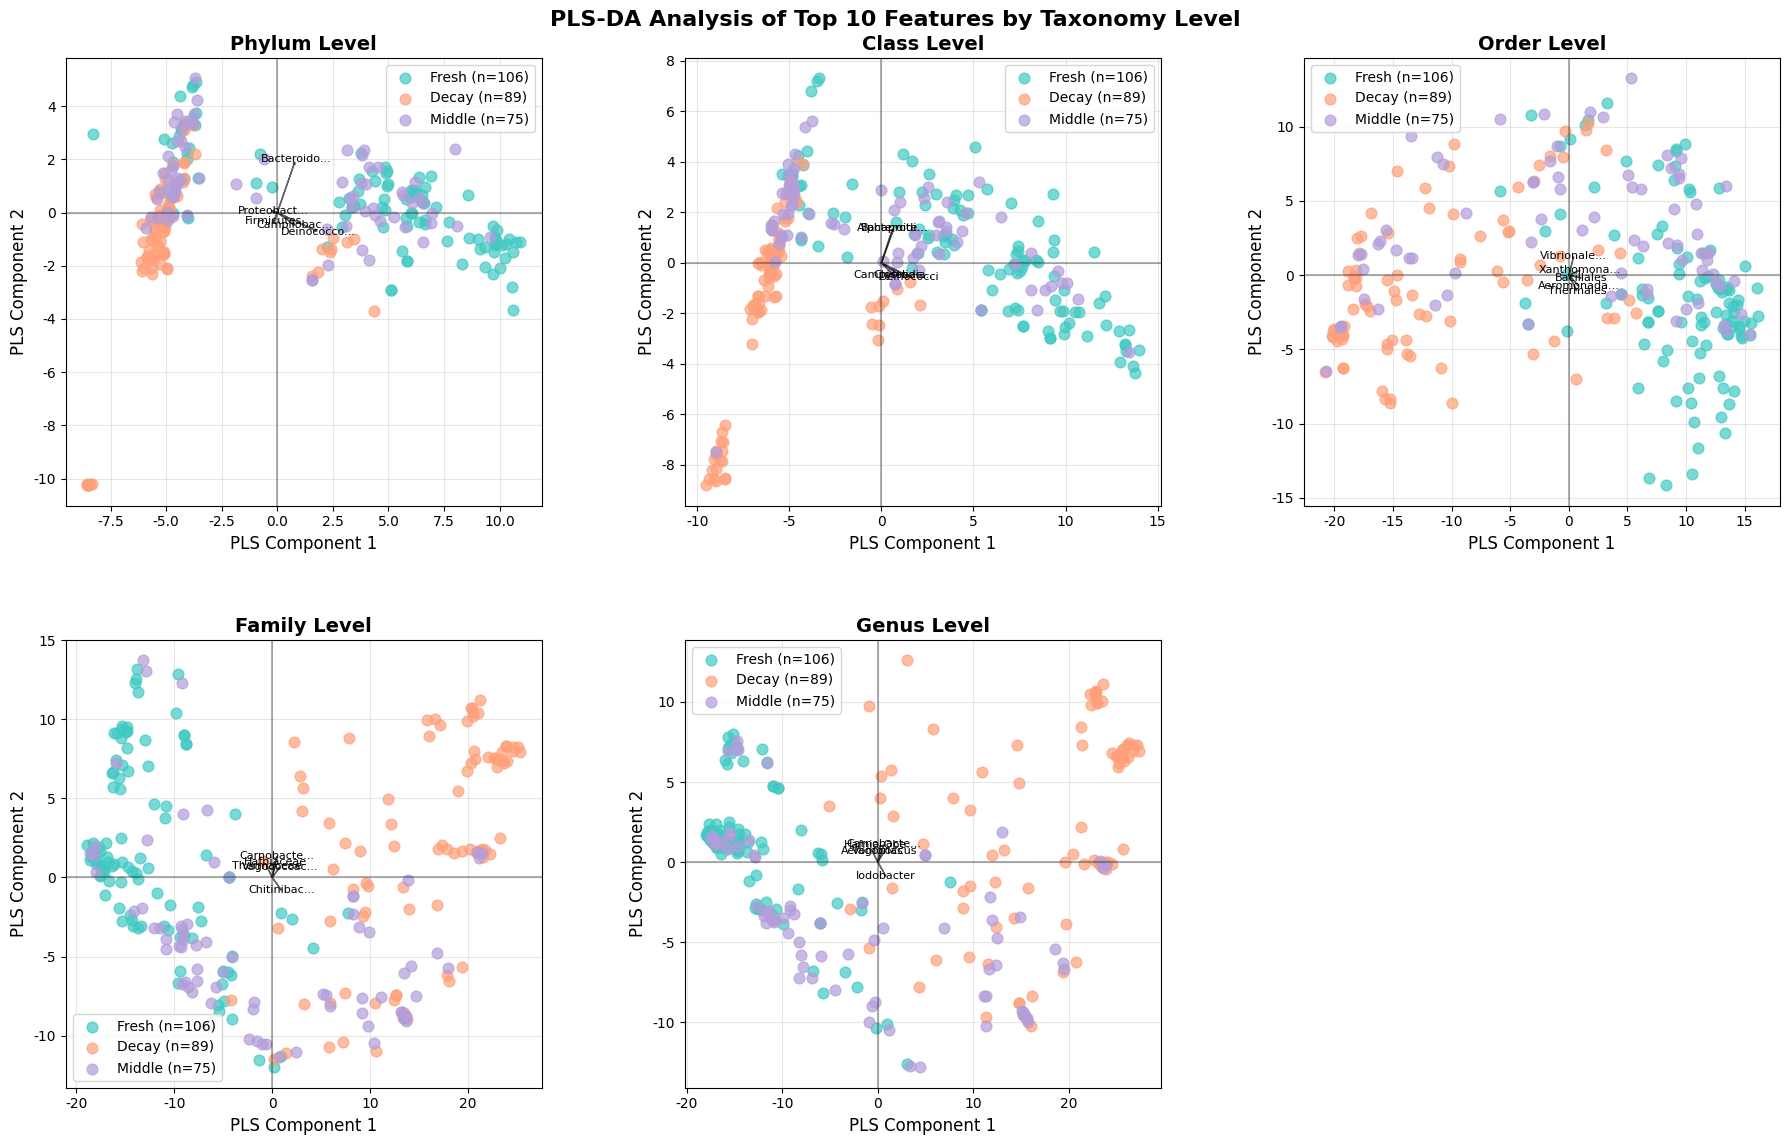

=== 모든 Level PLS-DA 분석 완료 ===

=== PLS-DA 분류 성능 요약 ===
Phylum  : Accuracy = 0.630 (63.0%)
Class   : Accuracy = 0.663 (66.3%)
Order   : Accuracy = 0.652 (65.2%)
Family  : Accuracy = 0.700 (70.0%)
Genus   : Accuracy = 0.719 (71.9%)

=== PLS-DA vs PCA 비교 ===
PLS-DA는 지도학습(Supervised) 방법으로 클래스 정보를 활용
PCA는 비지도학습(Unsupervised) 방법으로 분산 최대화

PLS-DA 장점:
- 클래스 분리에 최적화된 성분 추출
- 분류 성능 향상 가능
- Feature와 클래스 간 관계 파악


In [10]:
# Top 10 Feature PLS-DA 분석 (모든 taxonomy level)
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=== PLS-DA 분석 시작 ===\n")

# 모든 레벨 PLS-DA 결과 저장
all_plsda_results = {}

# 색상 및 라벨 설정 (PCA와 동일)
colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 1: "Decay", 2: "Middle"}

# Figure 생성 (3x2 = 6개 subplot, 하나는 빈 공간)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('PLS-DA Analysis of Top 10 Features by Taxonomy Level', 
             fontsize=16, fontweight='bold', y=0.95)

axes = axes.flatten()
level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

for idx, level_name in enumerate(level_names):
    print(f"{'='*60}")
    print(f"=== {level_name} Level PLS-DA 분석 ===")
    print(f"{'='*60}")
    
    # 해당 레벨 데이터 추출
    level_data = all_top10_data[level_name]
    X_top10 = level_data['X_top10']
    y_top10 = level_data['y_top10']
    feature_names = level_data['top_10_feature_names']
    
    # One-Hot Encoding for multi-class
    y_onehot = np.zeros((len(y_top10), 3))
    for i in range(len(y_top10)):
        y_onehot[i, y_top10[i]] = 1
    
    print(f"데이터 형태:")
    print(f"  X shape: {X_top10.shape}")
    print(f"  y shape: {y_top10.shape}")
    print(f"  y_onehot shape: {y_onehot.shape}")
    print(f"  클래스 분포: {np.bincount(y_top10)}")
    
    # PLS-DA 수행 (n_components=2로 시각화용)
    plsda = PLSRegression(n_components=2, scale=False)
    X_plsda = plsda.fit_transform(X_top10, y_onehot)[0]
    
    # 예측 결과
    y_pred_scores = plsda.predict(X_top10)
    y_pred = np.argmax(y_pred_scores, axis=1)
    
    # 정확도 계산
    accuracy = accuracy_score(y_top10, y_pred)
    
    # PLS-DA 결과 저장
    all_plsda_results[level_name] = {
        'plsda': plsda,
        'X_plsda': X_plsda,
        'y_pred': y_pred,
        'y_pred_scores': y_pred_scores,
        'accuracy': accuracy,
        'y_onehot': y_onehot
    }
    
    print(f"  정확도: {accuracy:.3f} ({accuracy*100:.1f}%)")
    
    # 현재 subplot 선택
    ax = axes[idx]
    
    # 각 라벨별로 scatter plot (색상 및 디자인 PCA와 동일)
    for label in [0, 1, 2]:
        mask = y_top10 == label
        if np.sum(mask) > 0:
            ax.scatter(X_plsda[mask, 0], X_plsda[mask, 1], 
                      c=colors[label], alpha=0.7, s=60,
                      label=f'{label_names[label]} (n={np.sum(mask)})')
    
    # Feature loading vectors (PLS 가중치, 벡터 색상 검정/테두리 없음)
    loadings = plsda.x_weights_ * 2
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_loading_indices = np.argsort(loading_magnitudes)[-5:]
    
    for i in top_loading_indices:
        ax.arrow(0, 0, loadings[i, 0], loadings[i, 1], 
                head_width=0.1, head_length=0.1, fc='black', ec='black', alpha=0.6)
        # Feature 이름 축약, 테두리 없는 텍스트
        feature_short = feature_names[i].replace('g__', '').replace('f__', '').replace('o__', '').replace('c__', '').replace('p__', '')
        if len(feature_short) > 10:
            feature_short = feature_short[:10] + '...'
        ax.text(loadings[i, 0]*1.1, loadings[i, 1]*1.1, feature_short,
               fontsize=8, ha='center', va='center')
    
    # 축 라벨 및 제목
    ax.set_xlabel('PLS Component 1', fontsize=12)
    ax.set_ylabel('PLS Component 2', fontsize=12)
    ax.set_title(f'{level_name} Level', fontsize=14, fontweight='bold')
    
    # 격자 및 중심선
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # 범례
    ax.legend(fontsize=10, loc='best')
    
    # 분류 성능 출력
    print(f"\n분류 리포트:")
    report = classification_report(y_top10, y_pred, 
                                 target_names=['Fresh', 'Decay', 'Middle'],
                                 output_dict=True, zero_division=0)
    print(f"  Fresh   - Precision: {report['Fresh']['precision']:.3f}, Recall: {report['Fresh']['recall']:.3f}, F1: {report['Fresh']['f1-score']:.3f}")
    print(f"  Decay   - Precision: {report['Decay']['precision']:.3f}, Recall: {report['Decay']['recall']:.3f}, F1: {report['Decay']['f1-score']:.3f}")
    print(f"  Middle  - Precision: {report['Middle']['precision']:.3f}, Recall: {report['Middle']['recall']:.3f}, F1: {report['Middle']['f1-score']:.3f}")
    print(f"  Macro Avg F1: {report['macro avg']['f1-score']:.3f}")
    print()

# 마지막 subplot 제거 (6개 중 5개만 사용)
fig.delaxes(axes[5])

plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.3, wspace=0.3)
plt.show()

print("=== 모든 Level PLS-DA 분석 완료 ===")
print("\n=== PLS-DA 분류 성능 요약 ===")
for level_name, results in all_plsda_results.items():
    accuracy = results['accuracy']
    print(f"{level_name:8s}: Accuracy = {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n" + "="*80)
print("=== PLS-DA vs PCA 비교 ===")
print("PLS-DA는 지도학습(Supervised) 방법으로 클래스 정보를 활용")
print("PCA는 비지도학습(Unsupervised) 방법으로 분산 최대화")
print("\nPLS-DA 장점:")
print("- 클래스 분리에 최적화된 성분 추출")
print("- 분류 성능 향상 가능")
print("- Feature와 클래스 간 관계 파악")

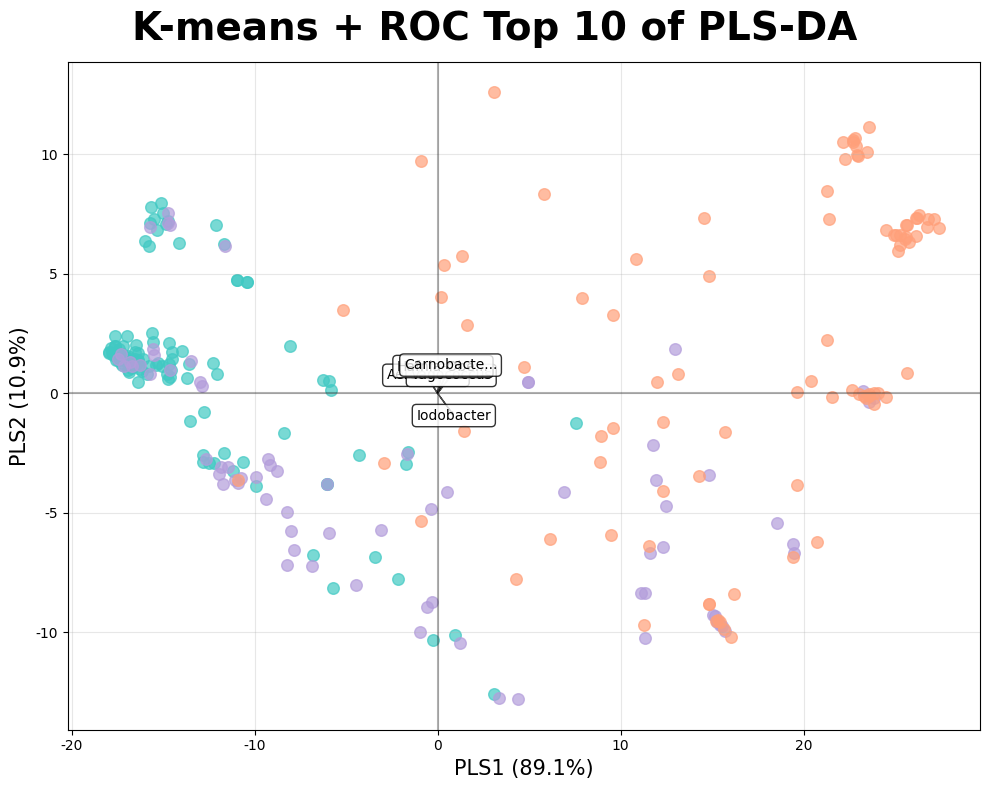

In [11]:
# Genus Level만 PLS-DA 단독 시각화 (Optuna + ROC Top 10 of PLS-DA, Condition 3)

from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import numpy as np

# 색상 및 라벨 설정 (Fresh, Middle, Spoilage 순서)
colors = {0: "#40c9c3", 2: "#b39ddb", 1: "#ffa07a"}
label_names = {0: "Fresh", 2: "Middle", 1: "Spoilage"}  # Decay → Spoilage

level_name = 'Genus'
level_data = all_top10_data[level_name]
X_top10 = level_data['X_top10']
y_top10 = level_data['y_top10']
feature_names = level_data['top_10_feature_names']

# One-hot encoding for multi-class
y_onehot = np.zeros((len(y_top10), 3))
for i in range(len(y_top10)):
    y_onehot[i, y_top10[i]] = 1

# PLS-DA 수행
plsda = PLSRegression(n_components=2, scale=False)
X_plsda = plsda.fit_transform(X_top10, y_onehot)[0]

# 각 성분별 설명력 계산
explained_var = np.var(X_plsda, axis=0) / np.sum(np.var(X_plsda, axis=0)) * 100
pls1_var = explained_var[0]
pls2_var = explained_var[1]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
fig.suptitle('K-means + ROC Top 10 of PLS-DA', fontsize=28, fontweight='bold', y=0.98)

# 각 라벨별로 scatter plot (Fresh, Middle, Spoilage 순서)
for label in [0, 2, 1]:
    mask = y_top10 == label
    if np.sum(mask) > 0:
        ax.scatter(X_plsda[mask, 0], X_plsda[mask, 1],
                   c=colors[label], alpha=0.7, s=70,
                   label=f'{label_names[label]} (n={np.sum(mask)})')

# Feature loading vectors (상위 5개만)
loadings = plsda.x_weights_ * 2
loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_loading_indices = np.argsort(loading_magnitudes)[-5:]

for i in top_loading_indices:
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.12, head_length=0.12, fc='black', ec='black', alpha=0.7)
    feature_short = feature_names[i].replace('g__', '').replace('f__', '').replace('o__', '').replace('c__', '').replace('p__', '')
    if len(feature_short) > 10:
        feature_short = feature_short[:10] + '...'
    ax.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, feature_short,
            fontsize=10, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))

# 축 라벨 및 제목 (PLS1/PLS2 % 포함)
ax.set_xlabel(f'PLS1 ({pls1_var:.1f}%)', fontsize=15)
ax.set_ylabel(f'PLS2 ({pls2_var:.1f}%)', fontsize=15)

# 격자 및 중심선
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)


plt.tight_layout()
plt.show()

### 3-1. PLS - DA Feature (VIP Score)

=== PLS-DA Feature Importance 분석 ===

=== Phylum Level PLS-DA Feature Importance ===

Phylum Level - Top 5 Most Important Features (VIP 기준):
------------------------------------------------------------------------------------------
 2. p__Bacteroidota
    VIP Score: 2.1981 (Very Important)
    PLS1: 0.3757 (positive)
    PLS2: 0.9084 (positive)

 1. p__Deinococcota
    VIP Score: 2.0280 (Very Important)
    PLS1: 0.8446 (positive)
    PLS2: 0.3303 (negative)

 3. p__Campilobacterota
    VIP Score: 0.9132 (Moderate)
    PLS1: 0.3501 (positive)
    PLS2: 0.2102 (negative)

 6. p__Firmicutes
    VIP Score: 0.3478 (Moderate)
    PLS1: 0.0679 (negative)
    PLS2: 0.1399 (negative)

 5. p__Proteobacteria
    VIP Score: 0.1827 (Moderate)
    PLS1: 0.0796 (negative)
    PLS2: 0.0186 (positive)

=== Class Level PLS-DA Feature Importance ===

Class Level - Top 5 Most Important Features (VIP 기준):
------------------------------------------------------------------------------------------
 1. c__Dei

/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/267183774.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, loc='lower right')
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/267183774.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, loc='lower right')
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/267183774.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, loc='lower right')
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/267183774.py:102: UserWarning: No artists with l

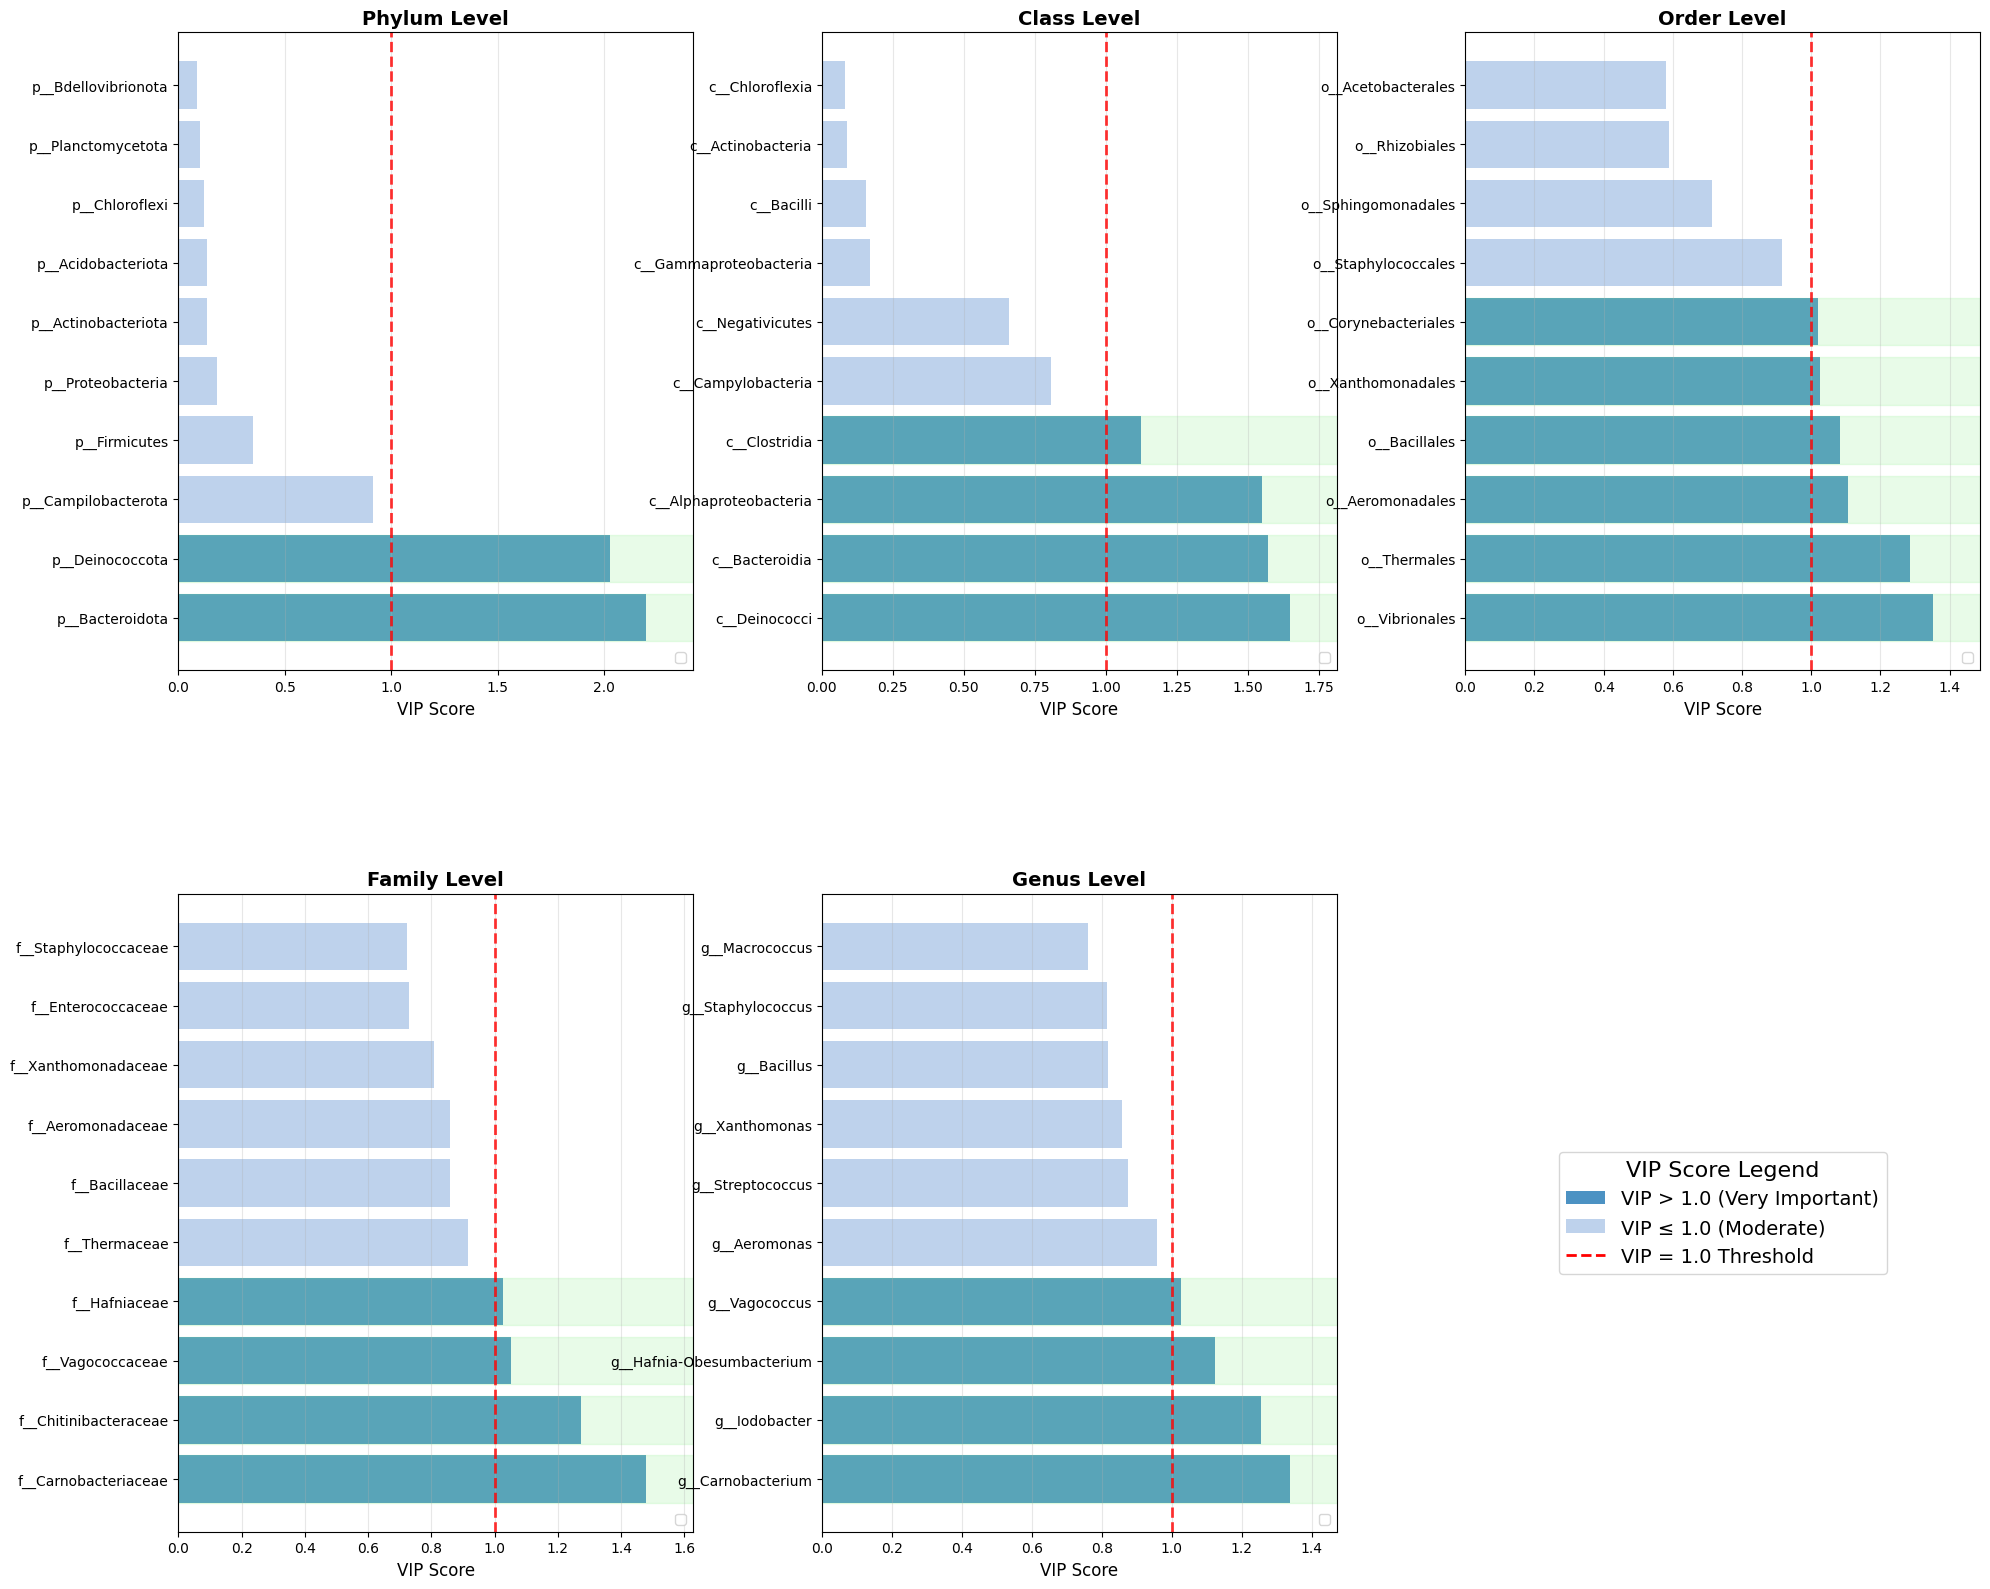


=== 각 Taxonomy Level별 가장 중요한 Feature 요약 (VIP 기준) ===
Phylum  : p__Bacteroidota
           VIP Score: 2.1981
           PLS1: 0.3757, PLS2: 0.9084
           VIP>1.0 Features: 2/10
           Classification Accuracy: 0.630

Class   : c__Deinococci
           VIP Score: 1.6474
           PLS1: 0.6931, PLS2: 0.2499
           VIP>1.0 Features: 4/10
           Classification Accuracy: 0.663

Order   : o__Vibrionales
           VIP Score: 1.3525
           PLS1: 0.1887, PLS2: 0.5746
           VIP>1.0 Features: 6/10
           Classification Accuracy: 0.652

Family  : f__Carnobacteriaceae
           VIP Score: 1.4803
           PLS1: 0.2231, PLS2: 0.6233
           VIP>1.0 Features: 4/10
           Classification Accuracy: 0.700

Genus   : g__Carnobacterium
           VIP Score: 1.3373
           PLS1: 0.3087, PLS2: 0.5122
           VIP>1.0 Features: 4/10
           Classification Accuracy: 0.719



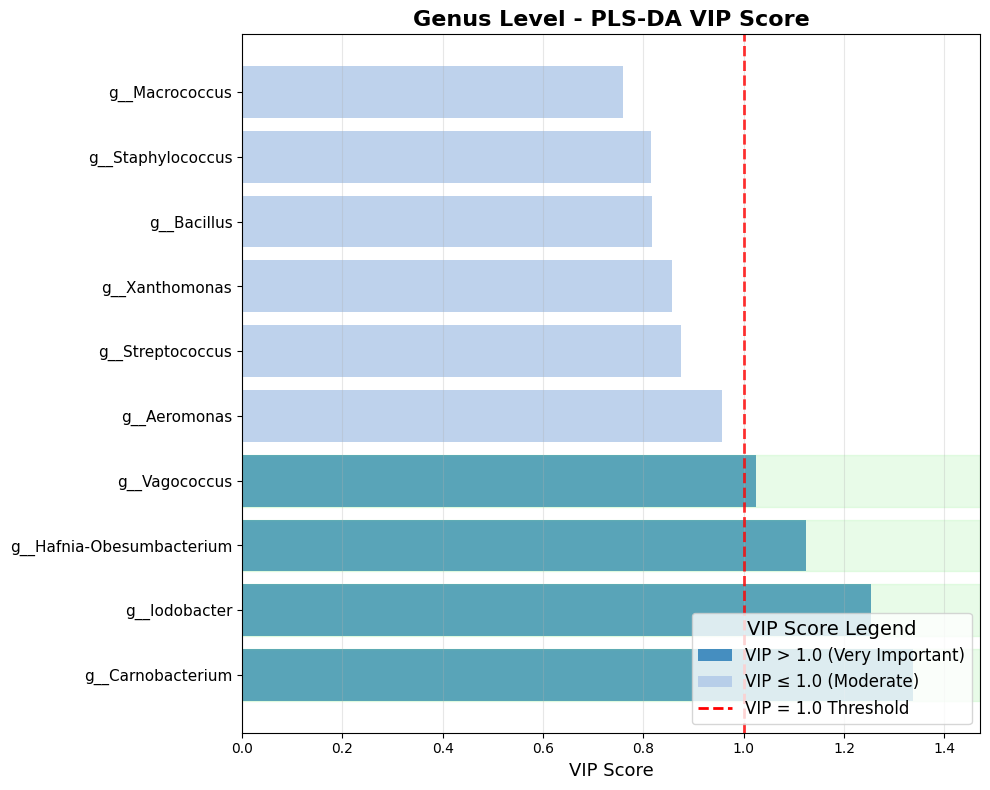

Genus Level - VIP Score Top Features
 7. g__Carnobacterium
    VIP Score: 1.3373 (Very Important)
    PLS1: 0.3087 (positive)
    PLS2: 0.5122 (positive)

 2. g__Iodobacter
    VIP Score: 1.2544 (Very Important)
    PLS1: 0.3867 (positive)
    PLS2: 0.4064 (negative)

10. g__Hafnia-Obesumbacterium
    VIP Score: 1.1238 (Very Important)
    PLS1: 0.1276 (positive)
    PLS2: 0.4861 (positive)

 8. g__Vagococcus
    VIP Score: 1.0252 (Very Important)
    PLS1: 0.3249 (positive)
    PLS2: 0.3235 (positive)

 9. g__Aeromonas
    VIP Score: 0.9566 (Moderate)
    PLS1: 0.2761 (negative)
    PLS2: 0.3268 (positive)



In [12]:
print("=== PLS-DA Feature Importance 분석 ===\n")

# 모든 레벨의 PLS-DA Feature Importance 결과 저장
all_plsda_importance = {}

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    print(f"{'='*60}")
    print(f"=== {level_name} Level PLS-DA Feature Importance ===")
    print(f"{'='*60}")
    
    # PLS-DA 결과 가져오기
    plsda_results = all_plsda_results[level_name]
    plsda = plsda_results['plsda']
    feature_names = all_top10_data[level_name]['top_10_feature_names']
    
    # PLS Component 1, 2에 대한 Feature Importance (x_weights_의 절댓값)
    pls1_importance = np.abs(plsda.x_weights_[:, 0])
    pls2_importance = np.abs(plsda.x_weights_[:, 1])
    
    # 전체 Importance (PLS1 + PLS2)
    total_importance = pls1_importance + pls2_importance
    
    # VIP (Variable Importance in Projection) 계산
    SS = np.sum(plsda.x_weights_**2, axis=1)
    vip_scores = np.sqrt(len(feature_names) * SS / np.sum(SS))
    
    # DataFrame 생성 (feature 이름 축약 없이 원본 사용)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'PLS1_Importance': pls1_importance,
        'PLS2_Importance': pls2_importance,
        'Total_Importance': total_importance,
        'VIP_Score': vip_scores,
        'PLS1_Direction': plsda.x_weights_[:, 0],  # 방향성 포함
        'PLS2_Direction': plsda.x_weights_[:, 1]   # 방향성 포함
    })
    
    # VIP Score로 정렬 (VIP > 1.0이 일반적으로 중요한 변수)
    importance_df = importance_df.sort_values('VIP_Score', ascending=False)
    
    # 결과 저장
    all_plsda_importance[level_name] = importance_df
    
    # 상위 5개 Feature 출력
    print(f"\n{level_name} Level - Top 5 Most Important Features (VIP 기준):")
    print("-" * 90)
    for i, row in importance_df.head(5).iterrows():
        vip_status = "Very Important" if row['VIP_Score'] > 1.0 else "Moderate"
        print(f"{row.name+1:2d}. {row['Feature']}")
        print(f"    VIP Score: {row['VIP_Score']:.4f} ({vip_status})")
        print(f"    PLS1: {row['PLS1_Importance']:.4f} ({'positive' if row['PLS1_Direction'] > 0 else 'negative'})")
        print(f"    PLS2: {row['PLS2_Importance']:.4f} ({'positive' if row['PLS2_Direction'] > 0 else 'negative'})")
        print()

print("\n" + "="*80)
print("=== 모든 Level PLS-DA Feature Importance 분석 완료 ===")

# PLS-DA Feature Importance 시각화 - VIP 기반 단일 바 차트
fig, axes = plt.subplots(2, 3, figsize=(20, 16))

axes = axes.flatten()

for idx, level_name in enumerate(['Phylum', 'Class', 'Order', 'Family', 'Genus']):
    ax = axes[idx]
    importance_df = all_plsda_importance[level_name]
    
    # Y축 위치 설정
    y_pos = np.arange(len(importance_df))
    
    # VIP > 1.0인 feature들 색상 구분
    colors_vip = ['#1f77b4' if vip > 1.0 else '#aec7e8' for vip in importance_df['VIP_Score']]
    
    # VIP Score 바 그래프 그리기
    bars = ax.barh(y_pos, importance_df['VIP_Score'], height=0.8,
                   alpha=0.8, color=colors_vip)
    
    # Y축 라벨 설정 (Feature 이름, 원본 그대로)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(importance_df['Feature'], fontsize=10)
    
    # 축 라벨 및 제목
    ax.set_xlabel('VIP Score', fontsize=12)
    ax.set_title(f'{level_name} Level', fontsize=14, fontweight='bold')
    
    # VIP=1.0 기준선 표시 (중요 변수 기준)
    ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.8, linewidth=2, 
    )
    
    # Grid 추가
    ax.grid(True, alpha=0.3, axis='x')
    
    # VIP > 1.0 영역 배경 색칠
    vip_important_count = np.sum(importance_df['VIP_Score'] > 1.0)
    if vip_important_count > 0:
        for i in range(vip_important_count):
            ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')
    
    # X축 범위 설정 (0부터 시작)
    ax.set_xlim(0, max(importance_df['VIP_Score'].max() * 1.1, 1.2))
    
    # 범례
    ax.legend(fontsize=10, loc='lower right')


# 마지막 subplot에 범례만 추가
legend_ax = axes[5]
legend_ax.axis('off')

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
]

legend_ax.legend(handles=legend_elements, loc='center', fontsize=14, 
                title='VIP Score Legend', title_fontsize=16)

plt.tight_layout()
plt.subplots_adjust(hspace=0.35, wspace=0.25)
plt.show()

print("\n" + "="*80)
print("=== 각 Taxonomy Level별 가장 중요한 Feature 요약 (VIP 기준) ===")
print("="*80)

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    importance_df = all_plsda_importance[level_name]
    top_feature = importance_df.iloc[0]
    vip_important_count = np.sum(importance_df['VIP_Score'] > 1.0)
    accuracy = all_plsda_results[level_name]['accuracy']
    
    print(f"{level_name:8s}: {top_feature['Feature']}")
    print(f"           VIP Score: {top_feature['VIP_Score']:.4f}")
    print(f"           PLS1: {top_feature['PLS1_Importance']:.4f}, PLS2: {top_feature['PLS2_Importance']:.4f}")
    print(f"           VIP>1.0 Features: {vip_important_count}/10")
    print(f"           Classification Accuracy: {accuracy:.3f}")
    print()

print("="*80)

# Genus Level - VIP Score 바 차트 단독 시각화
genus_df = all_plsda_importance['Genus']
y_pos = np.arange(len(genus_df))

fig, ax = plt.subplots(figsize=(10, 8))

# VIP > 1.0 색상 구분
colors_vip = ['#1f77b4' if vip > 1.0 else '#aec7e8' for vip in genus_df['VIP_Score']]

bars = ax.barh(y_pos, genus_df['VIP_Score'], height=0.8, alpha=0.8, color=colors_vip)

ax.set_yticks(y_pos)
ax.set_yticklabels(genus_df['Feature'], fontsize=11)
ax.set_xlabel('VIP Score', fontsize=13)
ax.set_title('Genus Level - PLS-DA VIP Score', fontsize=16, fontweight='bold')

# VIP=1.0 기준선
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.8, linewidth=2)

# Grid
ax.grid(True, alpha=0.3, axis='x')

# VIP > 1.0 영역 배경 색칠
vip_important_count = np.sum(genus_df['VIP_Score'] > 1.0)
if vip_important_count > 0:
    for i in range(vip_important_count):
        ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')

# X축 범위
ax.set_xlim(0, max(genus_df['VIP_Score'].max() * 1.1, 1.2))

# 범례
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=12, title='VIP Score Legend', title_fontsize=14)

plt.tight_layout()
plt.show()

print("="*80)
print("Genus Level - VIP Score Top Features")
for i, row in genus_df.head(5).iterrows():
    vip_status = "Very Important" if row['VIP_Score'] > 1.0 else "Moderate"
    print(f"{row.name+1:2d}. {row['Feature']}")
    print(f"    VIP Score: {row['VIP_Score']:.4f} ({vip_status})")
    print(f"    PLS1: {row['PLS1_Importance']:.4f} ({'positive' if row['PLS1_Direction'] > 0 else 'negative'})")
    print(f"    PLS2: {row['PLS2_Importance']:.4f} ({'positive' if row['PLS2_Direction'] > 0 else 'negative'})")
    print()
print("="*80)

## 4. 선택된 Feature들 끼리 상관관계 분석

=== 변화율 Top 10 Feature + TPC 상관관계 Heatmap ===


=== Phylum Level 상관관계 분석 ===


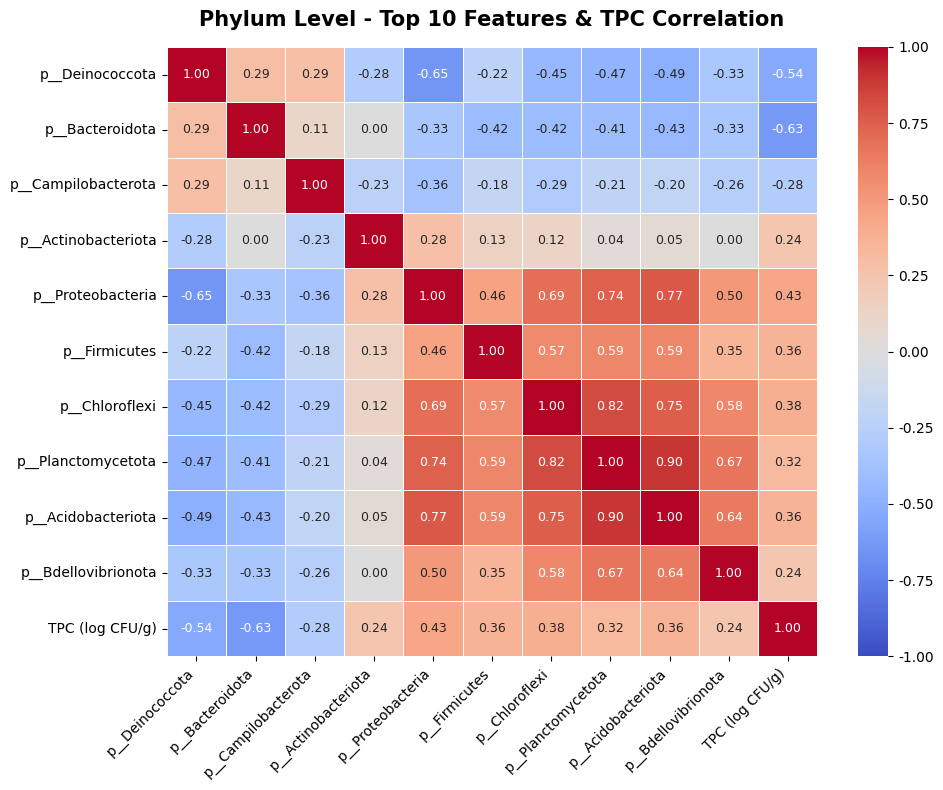

Phylum Level Heatmap 출력 완료


=== Class Level 상관관계 분석 ===


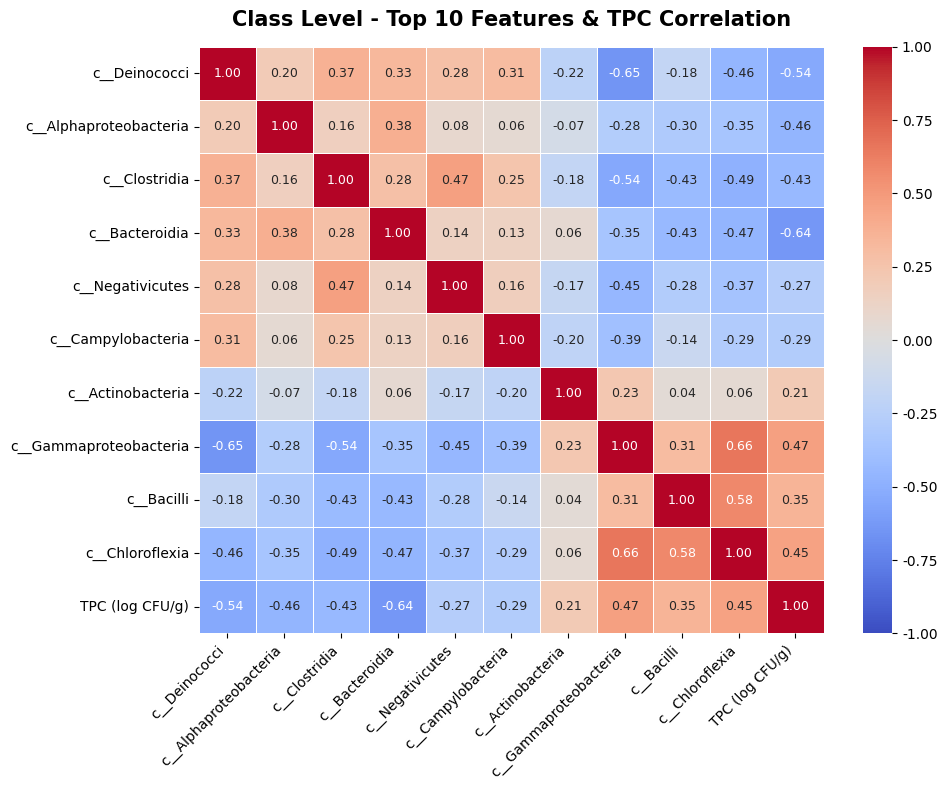

Class Level Heatmap 출력 완료


=== Order Level 상관관계 분석 ===


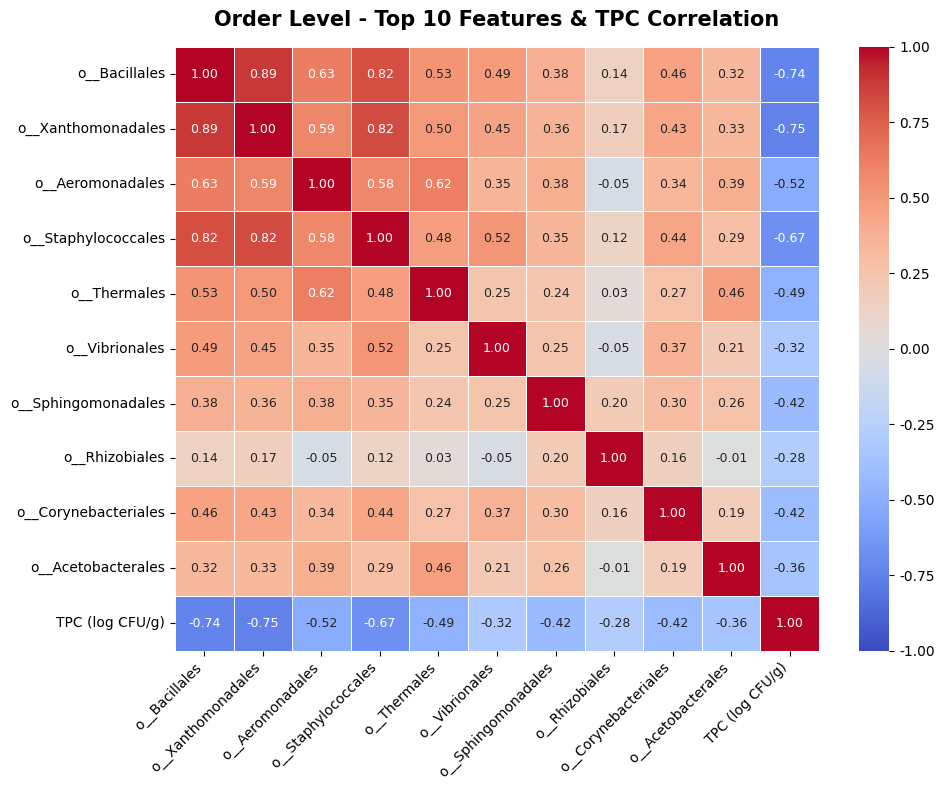

Order Level Heatmap 출력 완료


=== Family Level 상관관계 분석 ===


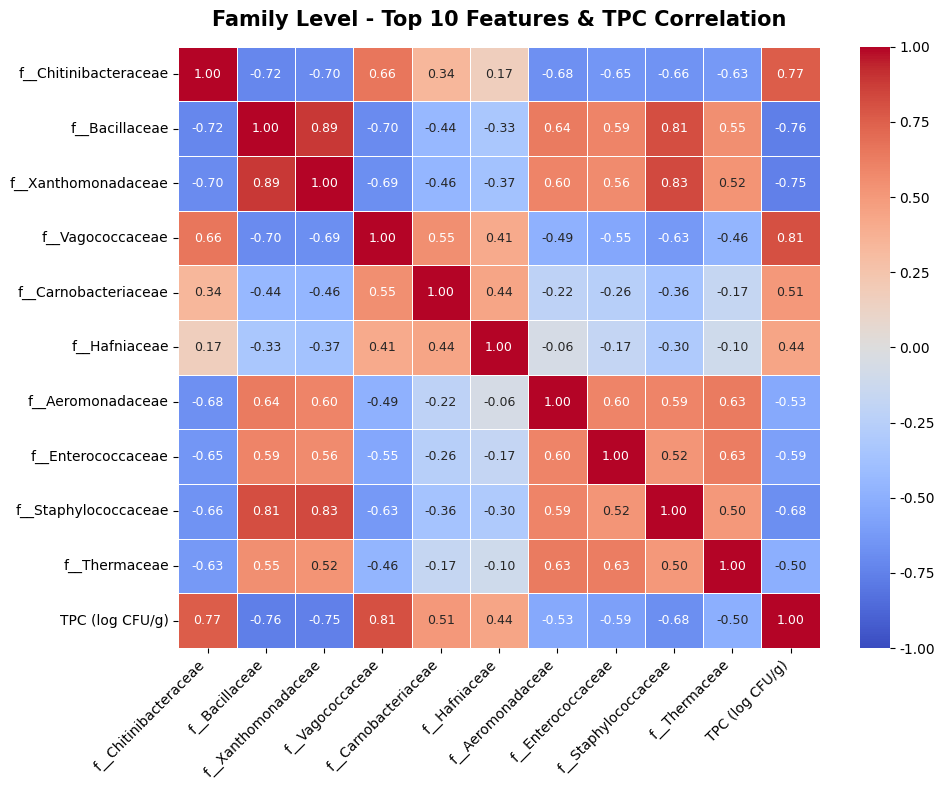

Family Level Heatmap 출력 완료


=== Genus Level 상관관계 분석 ===


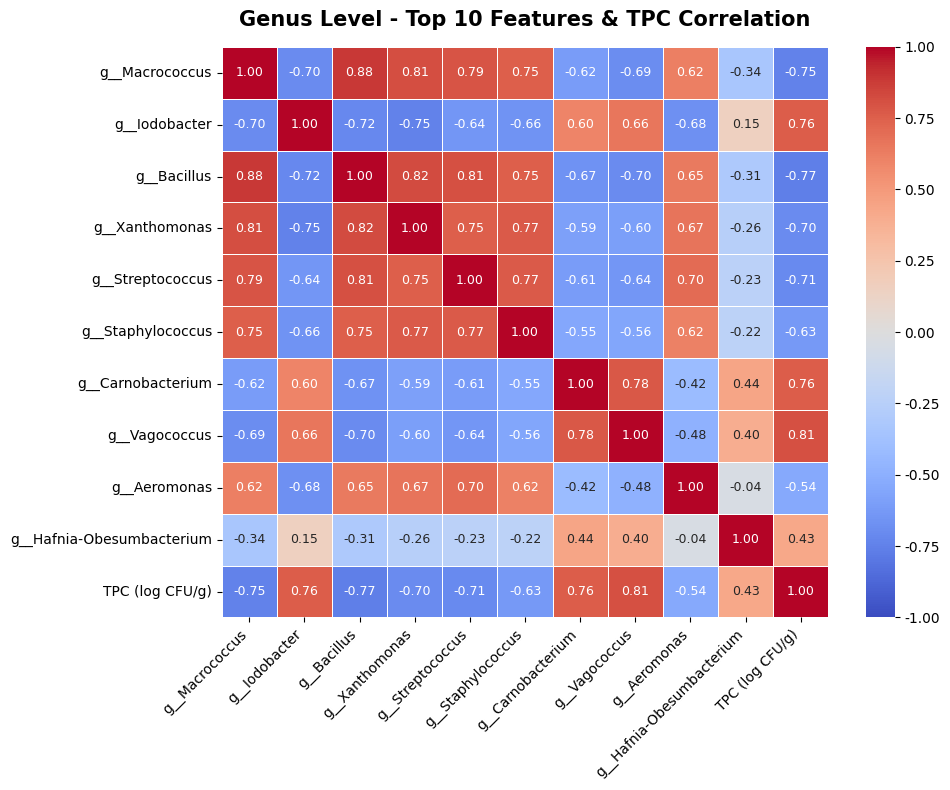

Genus Level Heatmap 출력 완료



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 변화율 Top 10 Feature + TPC 상관관계 Heatmap ===\n")

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    print(f"\n{'='*60}")
    print(f"=== {level_name} Level 상관관계 분석 ===")
    print(f"{'='*60}")

    # 해당 taxonomy level의 데이터
    top10_data = all_top10_data[level_name]['top10_data']
    feature_names = all_top10_data[level_name]['top_10_feature_names']

    # TPC 컬럼 포함해서 상관관계 분석
    corr_features = feature_names + ['TPC (log CFU/g)']
    corr_df = top10_data[corr_features]

    # 상관계수 계산
    corr_matrix = corr_df.corr(method='pearson')

    # Heatmap 출력
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
                vmin=-1, vmax=1, linewidths=0.5, cbar=True,
                annot_kws={"size": 9})
    plt.title(f"{level_name} Level - Top 10 Features & TPC Correlation", fontsize=15, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    print(f"{level_name} Level Heatmap 출력 완료\n")

=== 변화율 Top 10 Features에서 Hafnia 제외 ===
원본 Features 수: 10
제외된 Features: ['g__Hafnia-Obesumbacterium']
분석 Features 수: 9


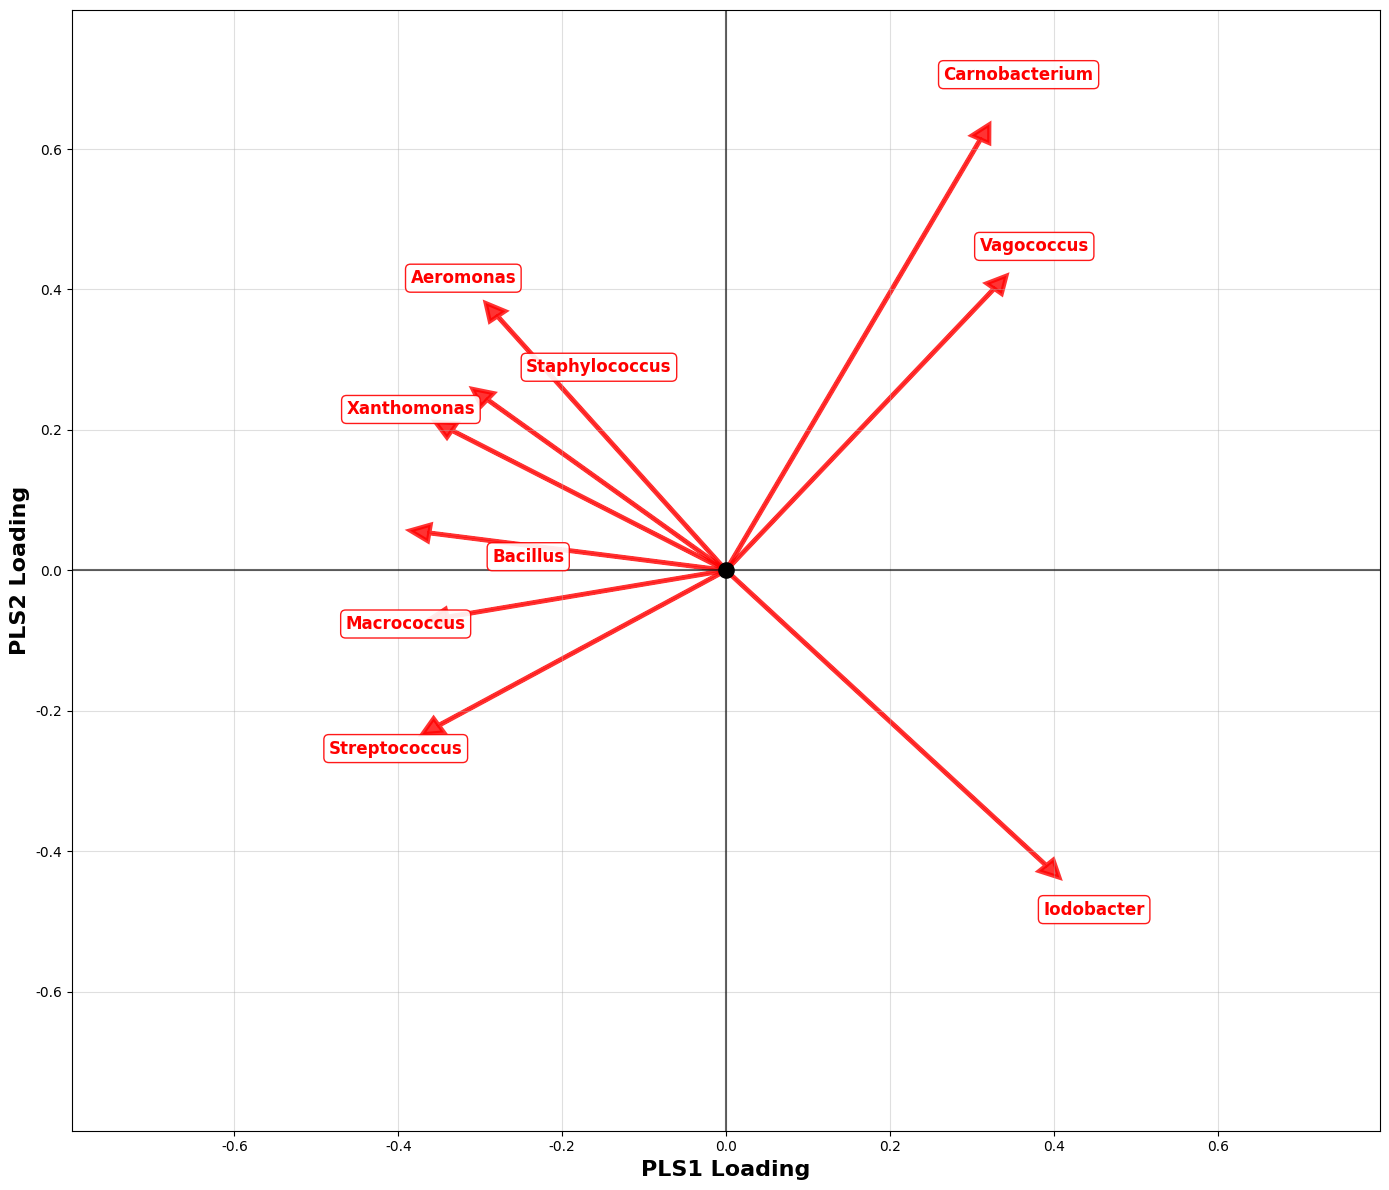

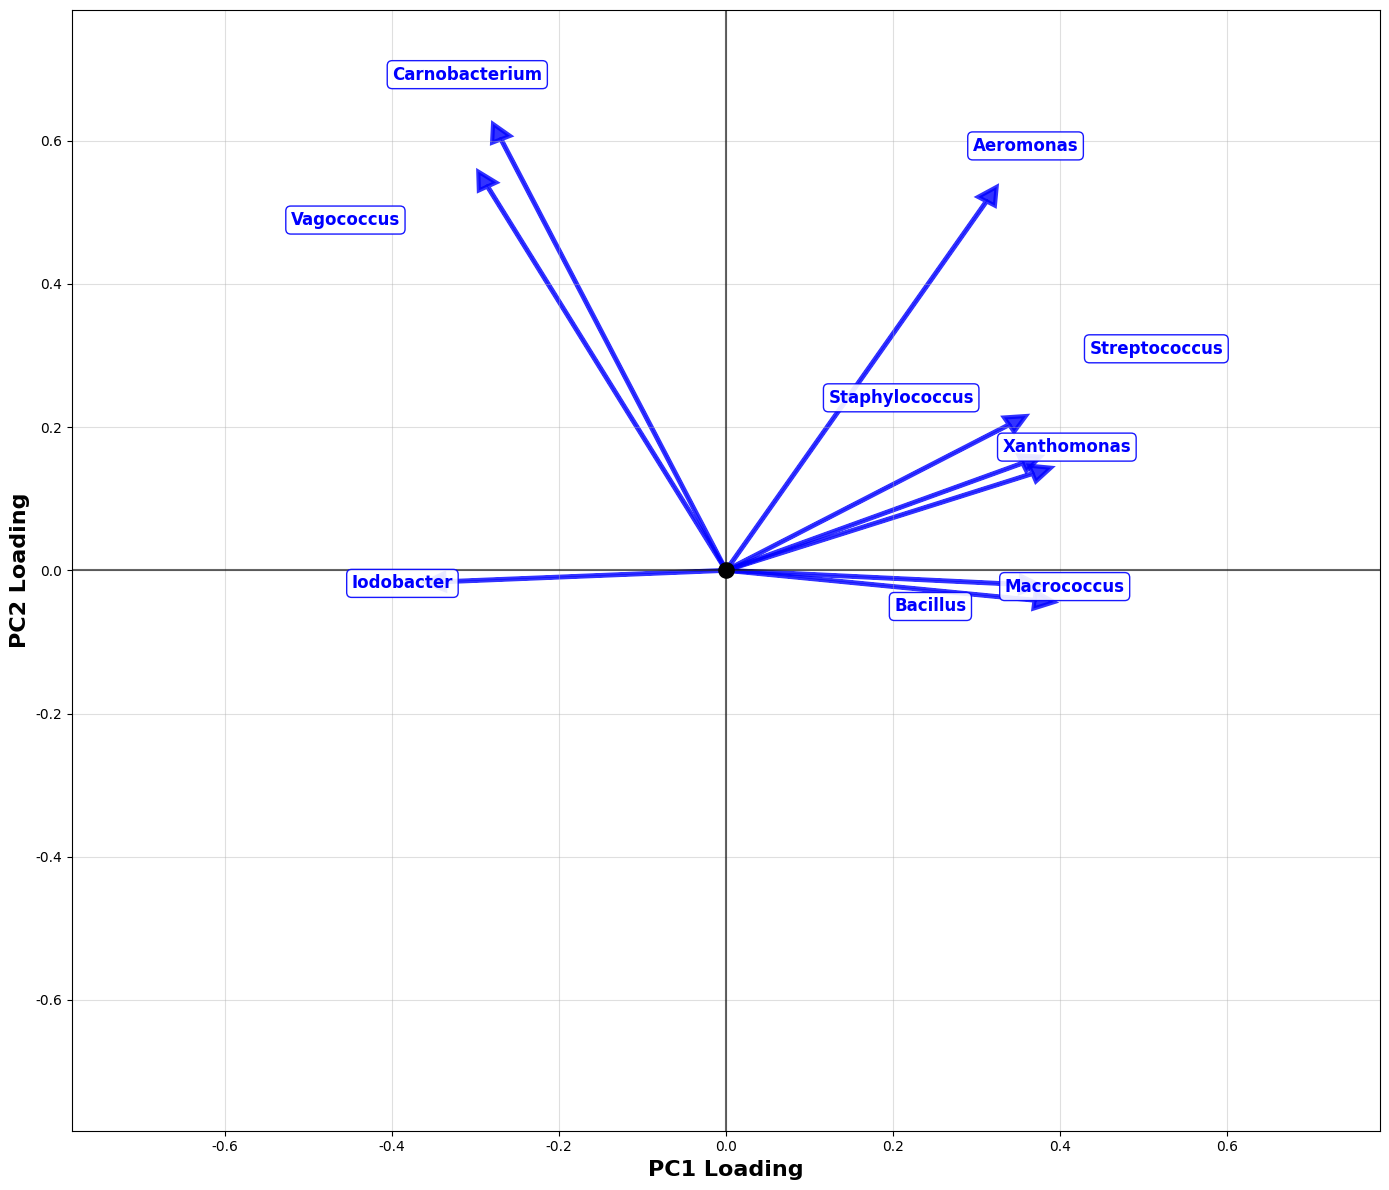

/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/29232049.py:232: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/29232049.py:232: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_5654/29232049.py:232: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/anacon

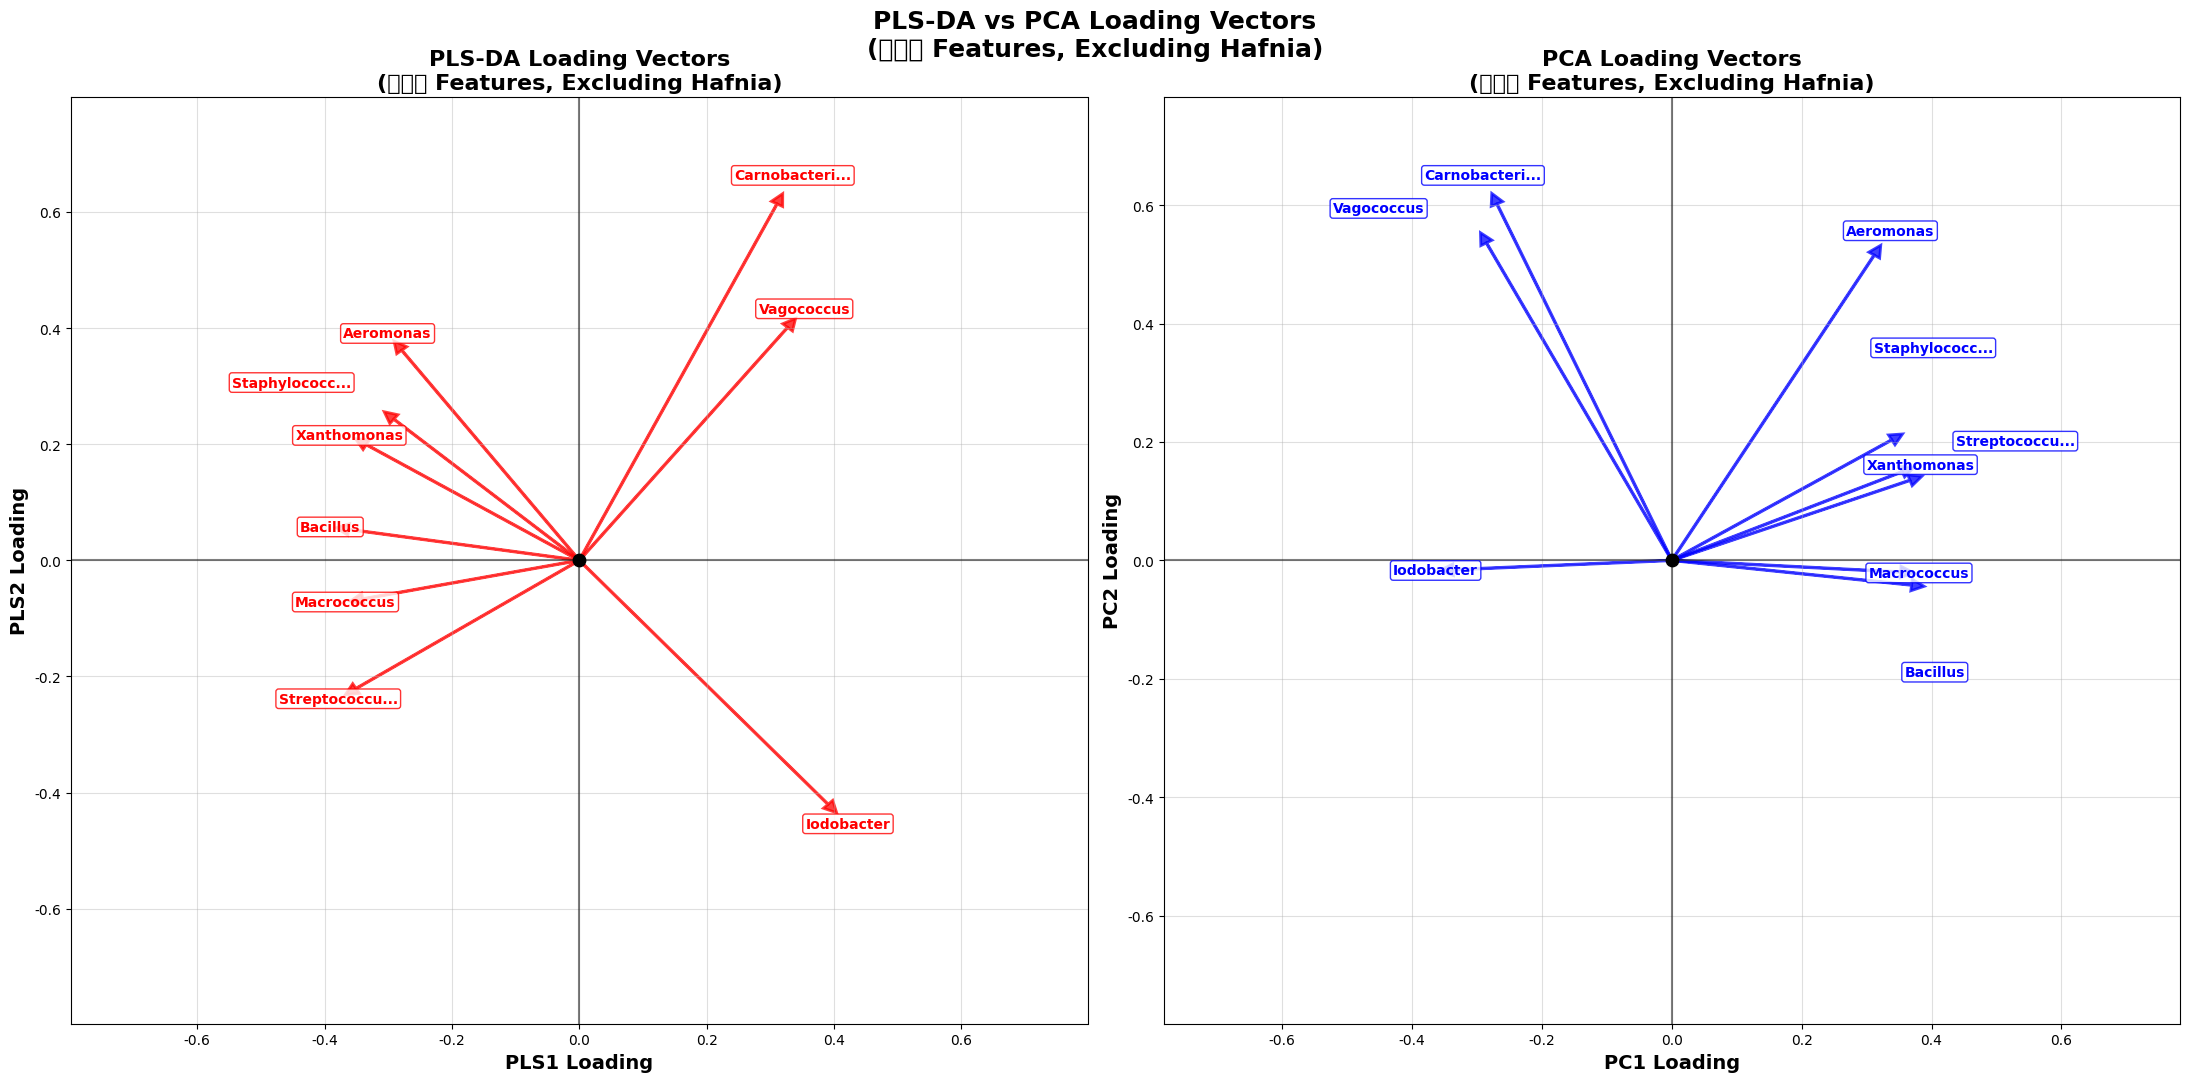


=== PLS-DA 벡터 정보 (Hafnia 제외한 9개) ===
Rank | Feature Name              | PLS1      | PLS2      | 크기
----------------------------------------------------------------------
 1   | Carnobacterium            |  +0.310 |  +0.614 |   0.688
 2   | Iodobacter                |  +0.391 |  -0.420 |   0.574
 3   | Vagococcus                |  +0.327 |  +0.401 |   0.518
 4   | Aeromonas                 |  -0.279 |  +0.362 |   0.457
 5   | Streptococcus             |  -0.351 |  -0.221 |   0.414
 6   | Xanthomonas               |  -0.334 |  +0.199 |   0.389
 7   | Staphylococcus            |  -0.291 |  +0.243 |   0.379
 8   | Bacillus                  |  -0.362 |  +0.053 |   0.366
 9   | Macrococcus               |  -0.340 |  -0.066 |   0.346

=== PCA 벡터 정보 (Hafnia 제외한 9개) ===
Rank | Feature Name              | PC1       | PC2       | 크기
----------------------------------------------------------------------
 1   | Carnobacterium            |  -0.269 |  +0.602 |   0.659
 2   | Vagococcus              

In [22]:
# PCA와 PLS-DA 벡터만 확대 시각화 (변화율 Top 10 Features 중 Hafnia 제외)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# Genus Level 데이터 사용
level_name = 'Genus'
level_data = all_top10_data[level_name]
original_feature_names = level_data['top_10_feature_names']

# Hafnia 제외한 features 선택
hafnia_features = [feat for feat in original_feature_names if 'Hafnia' in feat or 'Obesumbacterium' in feat]
filtered_feature_names = [feat for feat in original_feature_names if feat not in hafnia_features]

print(f"=== 변화율 Top 10 Features에서 Hafnia 제외 ===")
print(f"원본 Features 수: {len(original_feature_names)}")
print(f"제외된 Features: {hafnia_features}")
print(f"분석 Features 수: {len(filtered_feature_names)}")

if not filtered_feature_names:
    print("Hafnia 제외 후 분석할 features가 없습니다.")
else:
    # Hafnia 제외한 데이터로 재구성
    X_filtered = level_data['top10_data'][filtered_feature_names].values
    y_top10 = level_data['y_top10']

    # One-hot encoding for PLS-DA
    y_onehot = np.zeros((len(y_top10), 3))
    for i in range(len(y_top10)):
        y_onehot[i, y_top10[i]] = 1

    # PCA 수행
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_filtered)
    loadings_pca = pca.components_.T

    # PLS-DA 수행  
    plsda = PLSRegression(n_components=2, scale=False)
    X_plsda = plsda.fit_transform(X_filtered, y_onehot)[0]
    loadings_plsda = plsda.x_weights_

    # Loading magnitude 계산
    loading_magnitudes_pls = np.sqrt(loadings_plsda[:, 0]**2 + loadings_plsda[:, 1]**2)
    loading_magnitudes_pca = np.sqrt(loadings_pca[:, 0]**2 + loadings_pca[:, 1]**2)

    # 벡터 범위 자동 계산
    max_pls_vector = np.max(np.abs(loadings_plsda))
    max_pca_vector = np.max(np.abs(loadings_pca))
    pls_margin = max_pls_vector * 1.3
    pca_margin = max_pca_vector * 1.3

    def adjust_text_position(x, y, existing_positions, min_distance=0.15):
        """텍스트 위치를 조정하여 겹치지 않게 함"""
        adjusted_x, adjusted_y = x, y
        max_attempts = 20
        
        for attempt in range(max_attempts):
            collision = False
            for ex_x, ex_y in existing_positions:
                distance = np.sqrt((adjusted_x - ex_x)**2 + (adjusted_y - ex_y)**2)
                if distance < min_distance:
                    collision = True
                    # 충돌 시 위치 조정
                    angle = np.random.uniform(0, 2*np.pi)
                    offset = min_distance * 1.2
                    adjusted_x = x + offset * np.cos(angle)
                    adjusted_y = y + offset * np.sin(angle)
                    break
            
            if not collision:
                break
        
        return adjusted_x, adjusted_y

    # 1. PLS-DA 벡터만 확대 시각화
    plt.figure(figsize=(14, 12))

    text_positions = []  # 텍스트 위치 저장
    
    for i in range(len(filtered_feature_names)):
        feat_name = filtered_feature_names[i].replace('g__', '')
        if len(feat_name) > 15:
            feat_name = feat_name[:15] + '...'
        
        # 벡터 그리기 (모두 동일한 빨간색)
        plt.arrow(0, 0, loadings_plsda[i, 0], loadings_plsda[i, 1],
                 head_width=pls_margin*0.03, head_length=pls_margin*0.03, 
                 fc='red', ec='red', linewidth=3, alpha=0.8)
        
        # 텍스트 위치 계산 및 조정
        text_x = loadings_plsda[i, 0] * 1.15
        text_y = loadings_plsda[i, 1] * 1.15
        
        # 모든 텍스트 동일한 스타일 (색상 구분 없음)
        adjusted_x, adjusted_y = adjust_text_position(text_x, text_y, text_positions, min_distance=0.15)
        
        # 텍스트 라벨 (모두 동일한 스타일)
        plt.text(adjusted_x, adjusted_y, feat_name, 
                 fontsize=12, color='red', ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.9))
        
        text_positions.append((adjusted_x, adjusted_y))

    plt.xlim(-pls_margin, pls_margin)
    plt.ylim(-pls_margin, pls_margin)
    plt.xlabel('PLS1 Loading', fontsize=16, fontweight='bold')
    plt.ylabel('PLS2 Loading', fontsize=16, fontweight='bold')


    plt.grid(True, alpha=0.4)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.6, linewidth=1.5)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.6, linewidth=1.5)
    plt.scatter([0], [0], s=120, color='black', marker='o', zorder=10)
    plt.tight_layout()
    plt.show()

    # 2. PCA 벡터만 확대 시각화
    plt.figure(figsize=(14, 12))

    text_positions = []  # 텍스트 위치 초기화
    
    for i in range(len(filtered_feature_names)):
        feat_name = filtered_feature_names[i].replace('g__', '')
        if len(feat_name) > 15:
            feat_name = feat_name[:15] + '...'
        
        # 벡터 그리기 (모두 동일한 파란색)
        plt.arrow(0, 0, loadings_pca[i, 0], loadings_pca[i, 1],
                 head_width=pca_margin*0.03, head_length=pca_margin*0.03, 
                 fc='blue', ec='blue', linewidth=3, alpha=0.8)
        
        # 텍스트 위치 계산 및 조정
        text_x = loadings_pca[i, 0] * 1.15
        text_y = loadings_pca[i, 1] * 1.15
        
        # 모든 텍스트 동일한 스타일 (색상 구분 없음)
        adjusted_x, adjusted_y = adjust_text_position(text_x, text_y, text_positions, min_distance=0.15)
        
        # 텍스트 라벨 (모두 동일한 스타일)
        plt.text(adjusted_x, adjusted_y, feat_name, 
                 fontsize=12, color='blue', ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='blue', alpha=0.9))
        
        text_positions.append((adjusted_x, adjusted_y))

    plt.xlim(-pca_margin, pca_margin)
    plt.ylim(-pca_margin, pca_margin)
    plt.xlabel('PC1 Loading', fontsize=16, fontweight='bold')
    plt.ylabel('PC2 Loading', fontsize=16, fontweight='bold')


    plt.grid(True, alpha=0.4)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.6, linewidth=1.5)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.6, linewidth=1.5)
    plt.scatter([0], [0], s=120, color='black', marker='o', zorder=10)
    plt.tight_layout()
    plt.show()

    # 3. 벡터 비교 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 11))

    # PLS-DA 벡터
    text_positions = []
    for i in range(len(filtered_feature_names)):
        feat_name = filtered_feature_names[i].replace('g__', '')
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        
        ax1.arrow(0, 0, loadings_plsda[i, 0], loadings_plsda[i, 1],
                  head_width=pls_margin*0.025, head_length=pls_margin*0.025, 
                  fc='red', ec='red', alpha=0.75, linewidth=2)
        
        text_x = loadings_plsda[i, 0] * 1.08
        text_y = loadings_plsda[i, 1] * 1.08
        
        # 모든 텍스트 동일한 스타일
        adjusted_x, adjusted_y = adjust_text_position(text_x, text_y, text_positions, min_distance=0.12)
        
        ax1.text(adjusted_x, adjusted_y, feat_name, 
                 fontsize=10, color='red', ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='red', alpha=0.8))
        text_positions.append((adjusted_x, adjusted_y))

    ax1.set_xlim(-pls_margin, pls_margin)
    ax1.set_ylim(-pls_margin, pls_margin)
    ax1.set_xlabel('PLS1 Loading', fontsize=14, fontweight='bold')
    ax1.set_ylabel('PLS2 Loading', fontsize=14, fontweight='bold')
    ax1.set_title(f'PLS-DA Loading Vectors\n(변화율 Features, Excluding Hafnia)', 
                 fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.4)
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.5, linewidth=1.5)
    ax1.axvline(x=0, color='k', linestyle='-', alpha=0.5, linewidth=1.5)
    ax1.scatter([0], [0], s=80, color='black', marker='o', zorder=10)

    # PCA 벡터
    text_positions = []
    for i in range(len(filtered_feature_names)):
        feat_name = filtered_feature_names[i].replace('g__', '')
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        
        ax2.arrow(0, 0, loadings_pca[i, 0], loadings_pca[i, 1],
                  head_width=pca_margin*0.025, head_length=pca_margin*0.025, 
                  fc='blue', ec='blue', alpha=0.75, linewidth=2)
        
        text_x = loadings_pca[i, 0] * 1.08
        text_y = loadings_pca[i, 1] * 1.08
        
        # 모든 텍스트 동일한 스타일
        adjusted_x, adjusted_y = adjust_text_position(text_x, text_y, text_positions, min_distance=0.12)
        
        ax2.text(adjusted_x, adjusted_y, feat_name, 
                 fontsize=10, color='blue', ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='blue', alpha=0.8))
        text_positions.append((adjusted_x, adjusted_y))

    ax2.set_xlim(-pca_margin, pca_margin)
    ax2.set_ylim(-pca_margin, pca_margin)
    ax2.set_xlabel('PC1 Loading', fontsize=14, fontweight='bold')
    ax2.set_ylabel('PC2 Loading', fontsize=14, fontweight='bold')
    ax2.set_title(f'PCA Loading Vectors\n(변화율 Features, Excluding Hafnia)', 
                 fontsize=16, fontweight='bold')
    ax2.grid(True, alpha=0.4)
    ax2.axhline(y=0, color='k', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.axvline(x=0, color='k', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.scatter([0], [0], s=80, color='black', marker='o', zorder=10)

    plt.suptitle(f'PLS-DA vs PCA Loading Vectors\n(변화율 Features, Excluding Hafnia)', 
                 fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

    # 벡터 정보 출력
    print(f"\n=== PLS-DA 벡터 정보 (Hafnia 제외한 {len(filtered_feature_names)}개) ===")
    print("Rank | Feature Name              | PLS1      | PLS2      | 크기")
    print("-" * 70)
    sorted_idx_pls = np.argsort(loading_magnitudes_pls)[::-1]
    for rank, i in enumerate(sorted_idx_pls, 1):
        feat_name = filtered_feature_names[i].replace('g__', '')
        pls1_load = loadings_plsda[i, 0]
        pls2_load = loadings_plsda[i, 1]
        magnitude = loading_magnitudes_pls[i]
        print(f"{rank:2d}   | {feat_name:<25} | {pls1_load:+7.3f} | {pls2_load:+7.3f} | {magnitude:7.3f}")

    print(f"\n=== PCA 벡터 정보 (Hafnia 제외한 {len(filtered_feature_names)}개) ===")
    print("Rank | Feature Name              | PC1       | PC2       | 크기")
    print("-" * 70)
    sorted_idx_pca = np.argsort(loading_magnitudes_pca)[::-1]
    for rank, i in enumerate(sorted_idx_pca, 1):
        feat_name = filtered_feature_names[i].replace('g__', '')
        pc1_load = loadings_pca[i, 0]
        pc2_load = loadings_pca[i, 1]
        magnitude = loading_magnitudes_pca[i]
        print(f"{rank:2d}   | {feat_name:<25} | {pc1_load:+7.3f} | {pc2_load:+7.3f} | {magnitude:7.3f}")

    print(f"\n=== 분석 완료 ===")
    print(f"원본 변화율 Top 10 Features: {len(original_feature_names)}개")
    print(f"Hafnia 제외 후 Features: {len(filtered_feature_names)}개")
    if hafnia_features:
        print(f"제외된 Hafnia Features: {hafnia_features}")

=== Genus Level - Hafnia 제외하고 다음 순위로 대체 ===

제외할 Hafnia Features: ['g__Hafnia-Obesumbacterium']
유지되는 Features 수: 9
추가로 필요한 Features 수: 1
최종 Features 수: 10


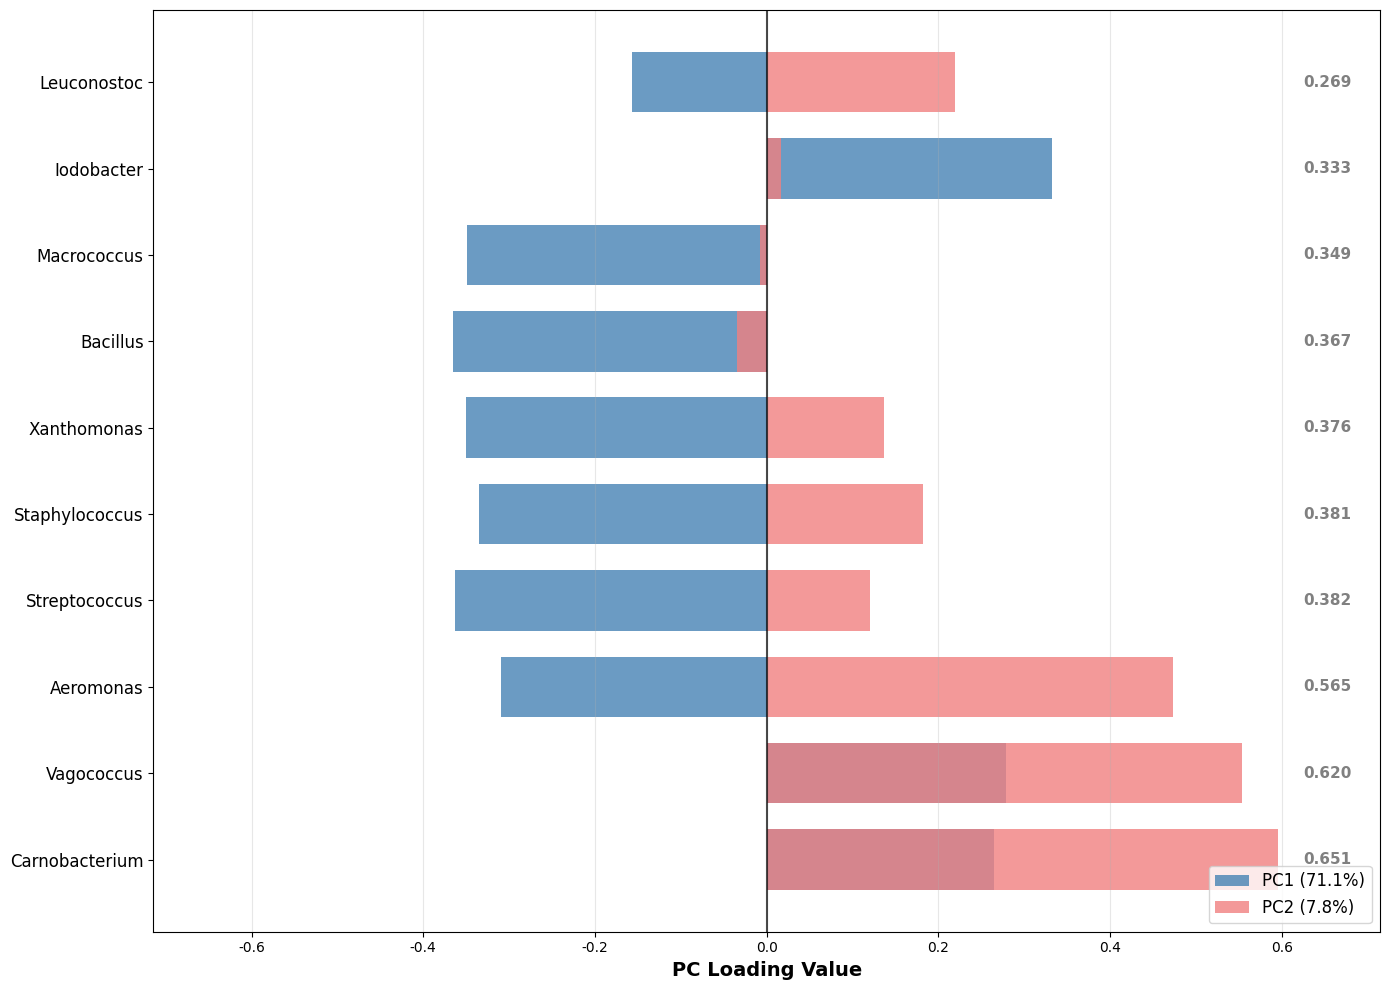

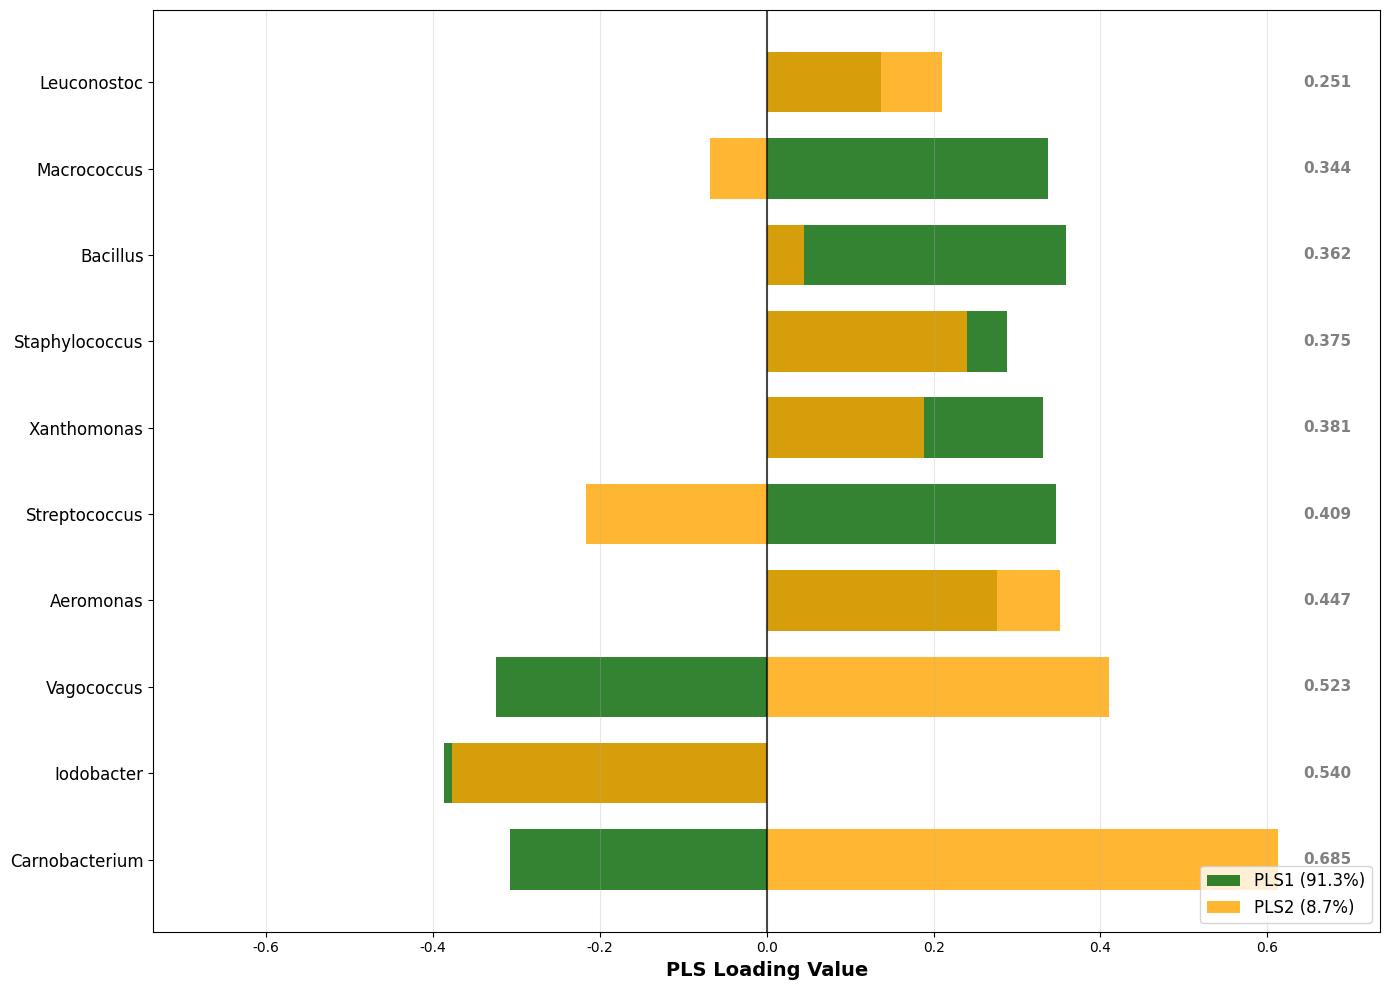

=== PCA Features Ranking (Vector Magnitude 내림차순) ===
 1위. Carnobacterium                 | Magnitude: 0.6514
 2위. Vagococcus                     | Magnitude: 0.6197
 3위. Aeromonas                      | Magnitude: 0.5649
 4위. Streptococcus                  | Magnitude: 0.3820
 5위. Staphylococcus                 | Magnitude: 0.3812
 6위. Xanthomonas                    | Magnitude: 0.3765
 7위. Bacillus                       | Magnitude: 0.3670
 8위. Macrococcus                    | Magnitude: 0.3492
 9위. Iodobacter                     | Magnitude: 0.3326
10위. Leuconostoc                    | Magnitude: 0.2691 (NEW)

=== PLS-DA Features Ranking (Vector Magnitude 내림차순) ===
 1위. Carnobacterium                 | Magnitude: 0.6852
 2위. Iodobacter                     | Magnitude: 0.5401
 3위. Vagococcus                     | Magnitude: 0.5230
 4위. Aeromonas                      | Magnitude: 0.4470
 5위. Streptococcus                  | Magnitude: 0.4094
 6위. Xanthomonas                    | Magnit

In [29]:
# Genus level PCA & PLS-DA Top 10 Feature Ranking (Hafnia 제외하고 다음 순위로 대체)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

level_name = 'Genus'
level_data = all_top10_data[level_name]
X_top10 = level_data['X_top10']
y_top10 = level_data['y_top10']
original_feature_names = level_data['top_10_feature_names']

print(f"=== {level_name} Level - Hafnia 제외하고 다음 순위로 대체 ===\n")

# 전체 변화율 데이터에서 추가 feature 가져오기
level_change_results = change_analysis_results[level_name]
all_ranked_features = level_change_results['top_10_features']

# Hafnia 포함된 feature 찾기
hafnia_features = [feat for feat in original_feature_names if 'Hafnia' in feat or 'Obesumbacterium' in feat]
print(f"제외할 Hafnia Features: {hafnia_features}")

# Hafnia 제외한 feature들
filtered_features = [feat for feat in original_feature_names if feat not in hafnia_features]
print(f"유지되는 Features 수: {len(filtered_features)}")

# 부족한 만큼 다음 순위에서 채우기 (전체 genus data에서)
genus_data_full = get_level_data('Genus')
all_genus_features = genus_data_full['feature_names']

# 변화율 기준으로 다음 순위 feature 찾기
excluded_count = len(hafnia_features)
needed_features = 10 - len(filtered_features)

print(f"추가로 필요한 Features 수: {needed_features}")

# 원래 top 10에 없으면서 Hafnia도 아닌 다음 순위 features 찾기
candidate_features = []
for feat in all_genus_features:
    if (feat not in original_feature_names and 
        'Hafnia' not in feat and 
        'Obesumbacterium' not in feat):
        candidate_features.append(feat)


additional_features = candidate_features[:needed_features] if candidate_features else []

# 최종 feature 리스트 (기존 + 추가)
final_feature_names = filtered_features + additional_features
print(f"최종 Features 수: {len(final_feature_names)}")

if len(final_feature_names) >= 8:
    # 새로운 데이터 매트릭스 구성
    genus_full_data = genus_data_full['features']
    X_new = genus_full_data[final_feature_names].values
    
    # PCA 분석
    pca = PCA(n_components=2)
    pca.fit(X_new)
    loadings_pca = pca.components_.T
    exp_var_pca = pca.explained_variance_ratio_ * 100
    
    # PLS-DA 분석
    y_onehot = np.zeros((len(y_top10), 3))
    for i in range(len(y_top10)):
        y_onehot[i, y_top10[i]] = 1
    
    plsda = PLSRegression(n_components=2, scale=False)
    X_pls_transformed = plsda.fit_transform(X_new, y_onehot)[0]
    loadings_pls = plsda.x_weights_
    
    # PLS explained variance 계산
    exp_var_pls = np.var(X_pls_transformed, axis=0) / np.sum(np.var(X_pls_transformed, axis=0)) * 100
    
    # Vector magnitude 계산
    magnitude_pca = np.sqrt(loadings_pca[:, 0]**2 + loadings_pca[:, 1]**2)
    magnitude_pls = np.sqrt(loadings_pls[:, 0]**2 + loadings_pls[:, 1]**2)
    
    # 전체 feature를 magnitude 기준 내림차순 정렬
    sorted_idx_pca = np.argsort(magnitude_pca)[::-1]  
    sorted_idx_pls = np.argsort(magnitude_pls)[::-1]  
    
    # Feature 이름에서 g__ 제거
    feature_names_clean = [f.replace('g__', '') for f in final_feature_names]
    
    # 1. PCA Feature Ranking Plot
    sorted_features_pca = [feature_names_clean[i] for i in sorted_idx_pca]
    sorted_pc1 = loadings_pca[sorted_idx_pca, 0]
    sorted_pc2 = loadings_pca[sorted_idx_pca, 1]
    sorted_mag_pca = magnitude_pca[sorted_idx_pca]
    
    y_pos = np.arange(len(sorted_features_pca))
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # PC1 (음수로 표시), PC2 (양수로 표시) - 모든 바 동일한 색상
    bars1 = ax.barh(y_pos, -sorted_pc1, height=0.7,
                     label=f"PC1 ({exp_var_pca[0]:.1f}%)",
                     alpha=0.8, color='steelblue')
    bars2 = ax.barh(y_pos, sorted_pc2, height=0.7,
                     label=f"PC2 ({exp_var_pca[1]:.1f}%)",
                     alpha=0.8, color='lightcoral')
    
    # Magnitude 값 표시
    for i, mag in enumerate(sorted_mag_pca):
        ax.text(max(np.abs(sorted_pc2))*1.05, i, f'{mag:.3f}', 
                ha='left', va='center', fontsize=11, fontweight='bold', color='gray')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_features_pca, fontsize=12)
    ax.set_xlabel('PC Loading Value', fontsize=14, fontweight='bold')

    
    ax.legend(fontsize=12, loc='lower right')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.grid(True, alpha=0.3, axis='x')
    
    max_val_pca = max(np.max(np.abs(sorted_pc1)), np.max(np.abs(sorted_pc2)))
    ax.set_xlim(-max_val_pca*1.2, max_val_pca*1.2)
    
    plt.tight_layout()
    plt.show()
    
    # 2. PLS-DA Feature Ranking Plot
    sorted_features_pls = [feature_names_clean[i] for i in sorted_idx_pls]
    sorted_pls1 = loadings_pls[sorted_idx_pls, 0]
    sorted_pls2 = loadings_pls[sorted_idx_pls, 1]
    sorted_mag_pls = magnitude_pls[sorted_idx_pls]
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # PLS1 (음수로 표시), PLS2 (양수로 표시) - 모든 바 동일한 색상
    bars3 = ax.barh(y_pos, -sorted_pls1, height=0.7,
                     label=f"PLS1 ({exp_var_pls[0]:.1f}%)",
                     alpha=0.8, color='darkgreen')
    bars4 = ax.barh(y_pos, sorted_pls2, height=0.7,
                     label=f"PLS2 ({exp_var_pls[1]:.1f}%)",
                     alpha=0.8, color='orange')
    
    # Magnitude 값 표시
    for i, mag in enumerate(sorted_mag_pls):
        ax.text(max(np.abs(sorted_pls2))*1.05, i, f'{mag:.3f}', 
                ha='left', va='center', fontsize=11, fontweight='bold', color='gray')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_features_pls, fontsize=12)
    ax.set_xlabel('PLS Loading Value', fontsize=14, fontweight='bold')

    
    ax.legend(fontsize=12, loc='lower right')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.grid(True, alpha=0.3, axis='x')
    
    max_val_pls = max(np.max(np.abs(sorted_pls1)), np.max(np.abs(sorted_pls2)))
    ax.set_xlim(-max_val_pls*1.2, max_val_pls*1.2)
    
    plt.tight_layout()
    plt.show()
    
    # 결과 출력
    print("=== PCA Features Ranking (Vector Magnitude 내림차순) ===")
    for rank, (feature, mag) in enumerate(zip(sorted_features_pca, sorted_mag_pca), 1):
        status = " (NEW)" if final_feature_names[sorted_idx_pca[rank-1]] in additional_features else ""
        print(f"{rank:2d}위. {feature:<30} | Magnitude: {mag:.4f}{status}")
    
    print("\n=== PLS-DA Features Ranking (Vector Magnitude 내림차순) ===")
    for rank, (feature, mag) in enumerate(zip(sorted_features_pls, sorted_mag_pls), 1):
        status = " (NEW)" if final_feature_names[sorted_idx_pls[rank-1]] in additional_features else ""
        print(f"{rank:2d}위. {feature:<30} | Magnitude: {mag:.4f}{status}")
    


print("="*80)
print(f"분석 요약:")
print(f"- 원본 Top 10: {len(original_feature_names)}개")
print(f"- 제외된 Hafnia: {len(hafnia_features)}개")
print(f"- 유지된 기존: {len(filtered_features)}개") 
print(f"- 추가된 대체: {len(additional_features)}개")
print(f"- 최종 분석: {len(final_feature_names)}개")
print("="*80)